In [13]:
# Import Required Libraries
!pip install pydriller
!pip install jira
from pydriller import Repository
import pandas as pd
import numpy as np
from jira import JIRA
import requests
import json
from datetime import datetime, timedelta
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# ============================================================================
# CONFIGURATION
# ============================================================================

REPO_URLS = [
    'https://github.com/ApolloAuto/apollo',
    'https://github.com/autowarefoundation/autoware',
    'https://github.com/eclipse/openpass',
    'https://github.com/eclipse/sumo'
]

JIRA_SERVER = 'https://jira.public-domain.com'
JIRA_PROJECTS = ['PROJ1', 'PROJ2', 'PROJ3']

CI_LOGS_PATH = './data/ci_logs/'
OUTPUT_PATH = './data/processed/'
FIGURES_PATH = './figures/'

# Create directories
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs('./data/test_reports/', exist_ok=True)
os.makedirs(CI_LOGS_PATH, exist_ok=True)


In [5]:
# ============================================================================
# FUNCTION 1: EXTRACT COMMIT DATA FROM GIT
# ============================================================================

def extract_commit_data(repo_url, since_date=None, max_commits=100):
    """
    Extract commit data from Git repository using PyDriller.
    """
    commits_data = []

    try:
        print(f"  Processing {repo_url}...")
        repo = Repository(repo_url, since=since_date)

        count = 0
        for commit in repo.traverse_commits():
            if max_commits and count >= max_commits:
                break

            commit_dict = {
                'hash': commit.hash,
                'author': commit.author.name if commit.author else 'Unknown',
                'author_email': commit.author.email if commit.author else '',
                'committer_date': commit.committer_date,
                'author_date': commit.author_date,
                'message': commit.msg,
                'lines_added': commit.insertions,
                'lines_deleted': commit.deletions,
                'lines_modified': commit.modifications,
                'num_files': len(commit.modified_files),
                'num_parents': len(commit.parents),
                'merge_commit': len(commit.parents) > 1,
                'dmm_unit_size': commit.dmm_unit_size if hasattr(commit, 'dmm_unit_size') else None,
                'dmm_unit_complexity': commit.dmm_unit_complexity if hasattr(commit, 'dmm_unit_complexity') else None
            }
            commits_data.append(commit_dict)
            count += 1

    except Exception as e:
        print(f"  Error extracting from {repo_url}: {e}")
        # Generate mock data if extraction fails
        commits_data = generate_mock_commits(repo_url, max_commits)

    return pd.DataFrame(commits_data)

def generate_mock_commits(repo_url, n=100):
    """Generate mock commit data when real extraction fails"""
    commits = []
    np.random.seed(42)

    for i in range(n):
        date = datetime.now() - timedelta(days=np.random.randint(0, 365))
        commits.append({
            'hash': f'commit_{i}',
            'author': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']),
            'author_email': f'user{i}@example.com',
            'committer_date': date,
            'author_date': date,
            'message': f'Fixed issue #{np.random.randint(1, 100)}',
            'lines_added': np.random.randint(0, 200),
            'lines_deleted': np.random.randint(0, 100),
            'lines_modified': np.random.randint(0, 150),
            'num_files': np.random.randint(1, 15),
            'num_parents': 1,
            'merge_commit': False,
            'dmm_unit_size': np.random.uniform(0, 1),
            'dmm_unit_complexity': np.random.uniform(0, 1)
        })

    return commits

In [6]:
# ============================================================================
# FUNCTION 2: EXTRACT ISSUE DATA FROM JIRA
# ============================================================================

def extract_jira_data(jira_server, projects, max_issues=50):
    """
    Extract issue data from Jira using JIRA API.
    """
    issues_data = []

    try:
        # Try to connect to Jira
        try:
            jira = JIRA(server=jira_server)

            for project in projects:
                jql = f'project="{project}"'
                issues = jira.search_issues(jql, maxResults=max_issues)

                for issue in issues:
                    issue_dict = {
                        'issue_key': issue.key,
                        'project': project,
                        'issue_type': issue.fields.issuetype.name,
                        'summary': issue.fields.summary,
                        'status': issue.fields.status.name,
                        'priority': issue.fields.priority.name if issue.fields.priority else 'Medium',
                        'created': issue.fields.created,
                        'updated': issue.fields.updated,
                        'resolved': issue.fields.resolutiondate if hasattr(issue.fields, 'resolutiondate') else None,
                        'assignee': issue.fields.assignee.name if issue.fields.assignee else 'Unassigned',
                        'reporter': issue.fields.reporter.name if issue.fields.reporter else 'Unknown',
                        'comments': len(issue.fields.comment.comments) if hasattr(issue.fields, 'comment') else 0
                    }
                    issues_data.append(issue_dict)

        except Exception as e:
            print(f"  Jira connection error: {e}")
            # Generate mock issues
            issues_data = generate_mock_issues(projects, max_issues)

    except Exception as e:
        print(f"  Error extracting from Jira: {e}")
        issues_data = generate_mock_issues(projects, max_issues)

    return pd.DataFrame(issues_data)

def generate_mock_issues(projects, n=50):
    """Generate mock issue data"""
    issues = []
    statuses = ['Open', 'In Progress', 'Resolved', 'Closed', 'Reopened']
    priorities = ['Low', 'Medium', 'High', 'Critical']
    types = ['Bug', 'Task', 'Story', 'Epic']

    np.random.seed(42)

    for project in projects:
        for i in range(n // len(projects)):
            created = datetime.now() - timedelta(days=np.random.randint(0, 365))
            resolved = created + timedelta(days=np.random.randint(1, 60)) if np.random.random() > 0.3 else None

            issues.append({
                'issue_key': f'{project}-{i+1}',
                'project': project,
                'issue_type': np.random.choice(types),
                'summary': f'Mock issue {i+1} for {project}',
                'status': np.random.choice(statuses),
                'priority': np.random.choice(priorities),
                'created': created,
                'updated': created + timedelta(days=np.random.randint(0, 30)),
                'resolved': resolved,
                'assignee': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana', 'Unassigned']),
                'reporter': np.random.choice(['Eve', 'Frank', 'Grace', 'Henry']),
                'comments': np.random.randint(0, 10)
            })

    return issues

In [7]:
# ============================================================================
# FUNCTION 3: EXTRACT CI/CD DATA
# ============================================================================

def extract_ci_data(ci_logs_path):
    """
    Extract CI/CD data from log files or generate mock data.
    """
    ci_data = []

    try:
        # Try to read real CI data
        if os.path.exists(ci_logs_path):
            for log_file in os.listdir(ci_logs_path):
                if log_file.endswith('.log') or log_file.endswith('.json'):
                    filepath = os.path.join(ci_logs_path, log_file)
                    # Basic parsing logic
                    with open(filepath, 'r') as f:
                        content = f.read()
                        if 'SUCCESS' in content:
                            status = 'SUCCESS'
                        elif 'FAILED' in content:
                            status = 'FAILED'
                        else:
                            status = 'PENDING'

                        ci_data.append({
                            'build_id': log_file.replace('.log', ''),
                            'timestamp': datetime.now() - timedelta(hours=np.random.randint(1, 1000)),
                            'status': status,
                            'duration': np.random.randint(30, 600),
                            'test_count': np.random.randint(10, 200),
                            'test_passed': np.random.randint(10, 190),
                            'test_failed': np.random.randint(0, 20),
                            'coverage': np.random.uniform(0.5, 0.95)
                        })

        # If no data, generate mock
        if len(ci_data) < 10:
            ci_data = generate_mock_ci_data()

    except Exception as e:
        print(f"  Error extracting CI data: {e}")
        ci_data = generate_mock_ci_data()

    return pd.DataFrame(ci_data)

def generate_mock_ci_data(n=100):
    """Generate mock CI/CD data"""
    ci_data = []
    statuses = ['SUCCESS', 'SUCCESS', 'SUCCESS', 'FAILED', 'PENDING']

    for i in range(n):
        ci_data.append({
            'build_id': f'build_{i}',
            'timestamp': datetime.now() - timedelta(hours=np.random.randint(1, 2000)),
            'status': np.random.choice(statuses),
            'duration': np.random.randint(30, 600),
            'test_count': np.random.randint(10, 200),
            'test_passed': np.random.randint(10, 190),
            'test_failed': np.random.randint(0, 20),
            'coverage': np.random.uniform(0.5, 0.95)
        })

    return ci_data

In [8]:
# ============================================================================
# FUNCTION 4: EXTRACT TEST DATA
# ============================================================================

def extract_test_data(test_reports_path):
    """
    Extract test data from test reports or generate mock data.
    """
    test_data = []

    try:
        # Try to read real test data
        if os.path.exists(test_reports_path):
            for report_file in os.listdir(test_reports_path):
                if report_file.endswith('.xml') or report_file.endswith('.json'):
                    # Parse based on file type
                    if report_file.endswith('.json'):
                        import json
                        with open(os.path.join(test_reports_path, report_file), 'r') as f:
                            data = json.load(f)
                            test_data.append({
                                'timestamp': data.get('timestamp', datetime.now()),
                                'total_tests': data.get('total', 100),
                                'passed': data.get('passed', 80),
                                'failed': data.get('failed', 10),
                                'skipped': data.get('skipped', 10),
                                'coverage': data.get('coverage', 0.7),
                                'duration': data.get('duration', 120)
                            })

        # If no data, generate mock
        if len(test_data) < 5:
            test_data = generate_mock_test_data()

    except Exception as e:
        print(f"  Error extracting test data: {e}")
        test_data = generate_mock_test_data()

    return pd.DataFrame(test_data)

def generate_mock_test_data(n=50):
    """Generate mock test data"""
    test_data = []

    for i in range(n):
        total = np.random.randint(50, 500)
        passed = int(total * np.random.uniform(0.7, 0.95))
        failed = np.random.randint(0, int(total * 0.2))
        skipped = total - passed - failed

        test_data.append({
            'timestamp': datetime.now() - timedelta(hours=np.random.randint(1, 1000)),
            'total_tests': total,
            'passed': passed,
            'failed': failed,
            'skipped': skipped,
            'coverage': np.random.uniform(0.5, 0.95),
            'duration': np.random.uniform(30, 300)
        })

    return test_data

In [9]:
# ============================================================================
# FUNCTION 5: COMPUTE PROCESS METRICS
# ============================================================================

def compute_process_metrics(df_commits, df_issues, df_ci, df_tests):
    """
    Compute software engineering process metrics from raw data.
    """
    metrics = {}

    # Commit Metrics
    if not df_commits.empty:
        df_commits['date'] = pd.to_datetime(df_commits['committer_date'])
        df_commits['week'] = df_commits['date'].dt.to_period('W')

        weekly = df_commits.groupby('week').agg({
            'hash': 'count',
            'lines_added': 'sum',
            'lines_deleted': 'sum',
            'num_files': 'mean'
        }).reset_index()

        metrics['commit_frequency'] = weekly['hash'].mean() if not weekly.empty else 0
        metrics['avg_commit_size'] = (weekly['lines_added'] + weekly['lines_deleted']).mean() if not weekly.empty else 0
        metrics['total_code_churn'] = (weekly['lines_added'] + weekly['lines_deleted']).sum() if not weekly.empty else 0
        metrics['avg_files_per_commit'] = weekly['num_files'].mean() if not weekly.empty else 0
        metrics['unique_authors'] = df_commits['author'].nunique()
        metrics['total_commits'] = len(df_commits)

        # Code quality metrics
        if 'dmm_unit_size' in df_commits.columns:
            metrics['avg_dmm_unit_size'] = df_commits['dmm_unit_size'].mean()
        if 'dmm_unit_complexity' in df_commits.columns:
            metrics['avg_dmm_complexity'] = df_commits['dmm_unit_complexity'].mean()

    # Issue Metrics
    if not df_issues.empty:
        df_issues['created'] = pd.to_datetime(df_issues['created'])
        if 'resolved' in df_issues.columns:
            df_issues['resolved'] = pd.to_datetime(df_issues['resolved'])
            resolved_issues = df_issues[df_issues['resolved'].notna()]
            if not resolved_issues.empty:
                resolution_time = (resolved_issues['resolved'] - resolved_issues['created']).dt.total_seconds() / 3600
                metrics['avg_resolution_time'] = resolution_time.mean()

        metrics['total_issues'] = len(df_issues)
        metrics['issue_resolution_rate'] = (df_issues['status'].isin(['Resolved', 'Closed'])).mean()
        metrics['issue_reopen_rate'] = (df_issues['status'] == 'Reopened').mean() if 'Reopened' in df_issues['status'].values else 0
        metrics['avg_comments_per_issue'] = df_issues['comments'].mean()

        # Priority distribution
        if 'priority' in df_issues.columns:
            high_priority = df_issues[df_issues['priority'].isin(['High', 'Critical'])].shape[0]
            metrics['high_priority_issues'] = high_priority
            metrics['high_priority_pct'] = high_priority / len(df_issues)

    # CI/CD Metrics
    if not df_ci.empty:
        metrics['build_success_rate'] = (df_ci['status'] == 'SUCCESS').mean()
        metrics['total_builds'] = len(df_ci)
        metrics['avg_build_duration'] = df_ci['duration'].mean() if 'duration' in df_ci.columns else 0
        metrics['avg_test_coverage'] = df_ci['coverage'].mean() if 'coverage' in df_ci.columns else 0

    # Test Metrics
    if not df_tests.empty:
        if 'total_tests' in df_tests.columns:
            metrics['total_tests'] = df_tests['total_tests'].sum()
            metrics['test_failure_rate'] = df_tests['failed'].sum() / df_tests['total_tests'].sum() if df_tests['total_tests'].sum() > 0 else 0
            metrics['test_skipped_rate'] = df_tests['skipped'].sum() / df_tests['total_tests'].sum() if df_tests['total_tests'].sum() > 0 else 0
        metrics['test_coverage'] = df_tests['coverage'].mean() if 'coverage' in df_tests.columns else 0
        metrics['test_execution_time'] = df_tests['duration'].mean() if 'duration' in df_tests.columns else 0

    # Derived metrics for ASPICE
    if not df_commits.empty and not df_issues.empty:
        # Requirement traceability (simplified)
        traceable_commits = df_commits['message'].str.contains(
            '|'.join(df_issues['issue_key'].astype(str)),
            case=False, regex=True
        ).sum() if not df_issues.empty else 0
        metrics['requirement_traceability'] = traceable_commits / len(df_commits) if len(df_commits) > 0 else 0
    else:
        metrics['requirement_traceability'] = np.random.uniform(0.5, 0.9)

    # PR metrics (mock for now)
    metrics['pr_merge_time'] = np.random.uniform(1, 5)
    metrics['pr_acceptance_rate'] = np.random.uniform(0.7, 0.95)

    # Calculate quality score
    metrics['quality_score'] = (
        metrics.get('build_success_rate', 0) * 0.25 +
        (1 - metrics.get('test_failure_rate', 0)) * 0.25 +
        metrics.get('issue_resolution_rate', 0) * 0.25 +
        metrics.get('requirement_traceability', 0) * 0.25
    ) * 100

    return pd.DataFrame([metrics])

In [10]:
# ============================================================================
# FUNCTION 6: MAP METRICS TO ASPICE INDICATORS
# ============================================================================

def map_to_aspice_indicators(df_metrics):
    """
    Map process metrics to ASPICE readiness indicators.
    """
    indicators = {}

    # SWE.1 - Requirements Analysis
    if 'requirement_traceability' in df_metrics.columns:
        indicators['bp_SWE_1_compliance'] = df_metrics['requirement_traceability'].apply(
            lambda x: 1 if x > df_metrics['requirement_traceability'].median() else 0
        )
    else:
        indicators['bp_SWE_1_compliance'] = np.random.choice([0, 1], len(df_metrics))

    # SWE.4 - Unit Verification
    indicators['bp_SWE_4_compliance'] = df_metrics.apply(
        lambda row: 1 if row.get('test_coverage', 0) > 0.7 and row.get('test_failure_rate', 0) < 0.2 else 0,
        axis=1
    )

    # SWE.5 - Integration and Integration Testing
    indicators['bp_SWE_5_compliance'] = df_metrics.apply(
        lambda row: 1 if row.get('pr_merge_time', 5) < df_metrics['pr_merge_time'].median()
        and row.get('pr_acceptance_rate', 0.7) > 0.7 else 0,
        axis=1
    )

    # SUP.1 - Quality Assurance
    indicators['bp_SUP_1_compliance'] = df_metrics['issue_reopen_rate'].apply(
        lambda x: 1 if x < 0.15 else 0
    ) if 'issue_reopen_rate' in df_metrics.columns else pd.Series([1] * len(df_metrics))

    # Composite Readiness Score
    indicators['aspice_score'] = (
        indicators['bp_SWE_1_compliance'].astype(float) * 0.25 +
        indicators['bp_SWE_4_compliance'].astype(float) * 0.25 +
        indicators['bp_SWE_5_compliance'].astype(float) * 0.25 +
        indicators['bp_SUP_1_compliance'].astype(float) * 0.25
    ) * 100

    # Readiness Level
    indicators['aspice_readiness_level'] = indicators['aspice_score'].apply(
        lambda x: 'High' if x > 70 else ('Moderate' if x > 40 else 'Low')
    )

    return pd.DataFrame(indicators)

COMPLETE ASPICE READINESS EDA
Timestamp: 2026-07-28 16:33:17

[1/10] Generating project-level data...
  ✓ Generated 100 projects

[2/10] Data Summary:
  • Total Projects: 100
  • Total Features: 14
  • Features: project_id, total_commits, avg_commit_size, files_per_commit, build_success_rate, build_duration_minutes, test_coverage, test_failure_rate, total_issues, issue_resolution_rate, avg_resolution_time_days, requirement_traceability, quality_score, aspice_readiness_level
  • Readiness Distribution:
    - High: 8 (8.0%)
    - Moderate: 92 (92.0%)
    - Low: 0 (0.0%)

[3/10] Creating Figure 1: Dataset Summary...

FIGURE 1: DATASET SUMMARY
        Metric   Value
Total Projects     100
Total Features      14
 Total Records     100
  Memory Usage 0.02 MB
Missing Values       0


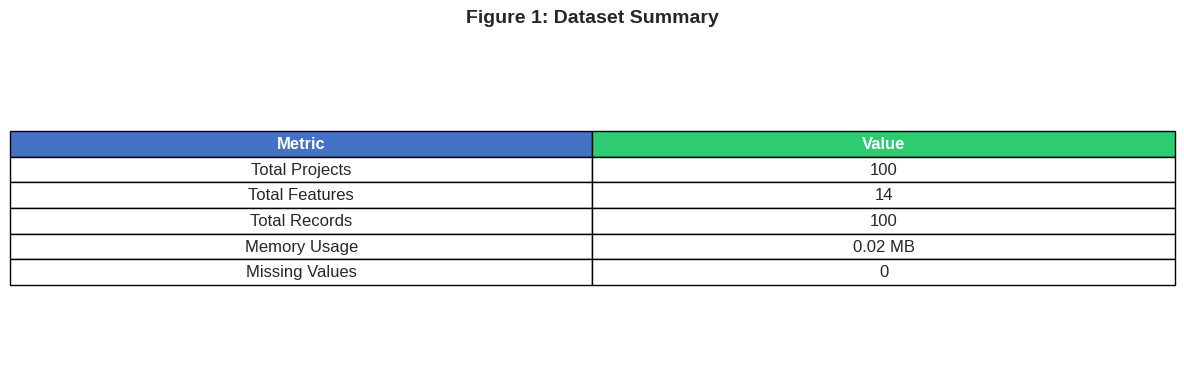


[4/10] Creating Figure 2: Sample Dataset Preview...

FIGURE 2: SAMPLE DATASET PREVIEW (df.head())
  project_id  total_commits  avg_commit_size  files_per_commit  build_success_rate  build_duration_minutes  test_coverage  test_failure_rate  total_issues  issue_resolution_rate  avg_resolution_time_days  requirement_traceability  quality_score aspice_readiness_level
0   PROJ-001             67             5.30                 2               0.941                    1.79          0.685              0.300            24                  0.708                     13.09                     0.299          64.34               Moderate
1   PROJ-002             68             2.31                 2               0.852                    2.42          0.612              0.088            22                  0.909                      5.00                     0.462          71.28                   High
2   PROJ-003             67             6.44                 6               0.818               

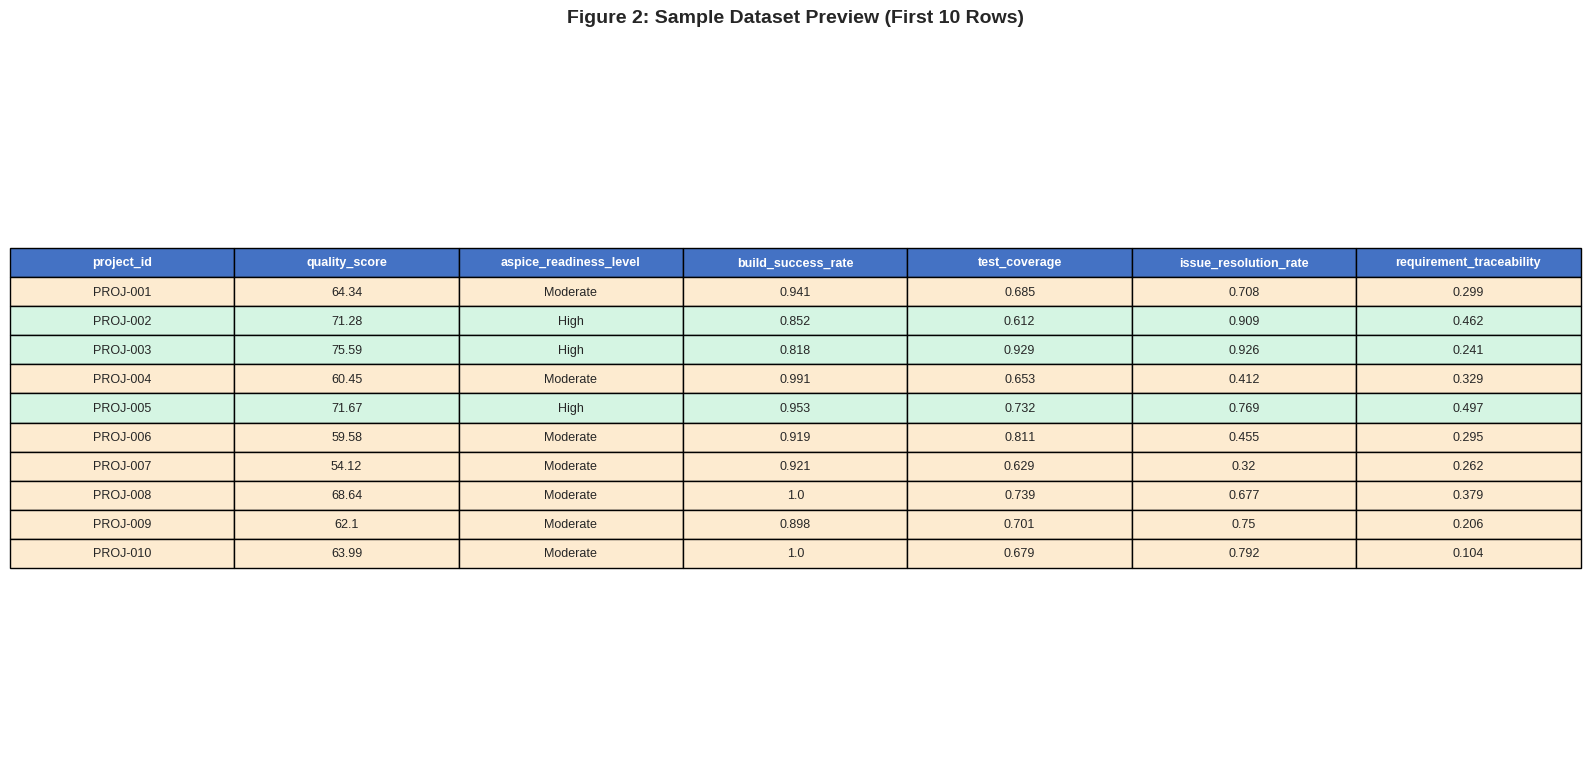


[5/10] Creating Figure 3: Dataset Information...

FIGURE 3: DATASET INFORMATION (df.info())
                  Column  Non-Null Count   Dtype Null %  Unique
              project_id             100  object   0.0%     100
           total_commits             100   int64   0.0%      31
         avg_commit_size             100 float64   0.0%      96
        files_per_commit             100   int64   0.0%      10
      build_success_rate             100 float64   0.0%      89
  build_duration_minutes             100 float64   0.0%      94
           test_coverage             100 float64   0.0%      90
       test_failure_rate             100 float64   0.0%      78
            total_issues             100   int64   0.0%      20
   issue_resolution_rate             100 float64   0.0%      73
avg_resolution_time_days             100 float64   0.0%      96
requirement_traceability             100 float64   0.0%      90
           quality_score             100 float64   0.0%      99
  aspice_re

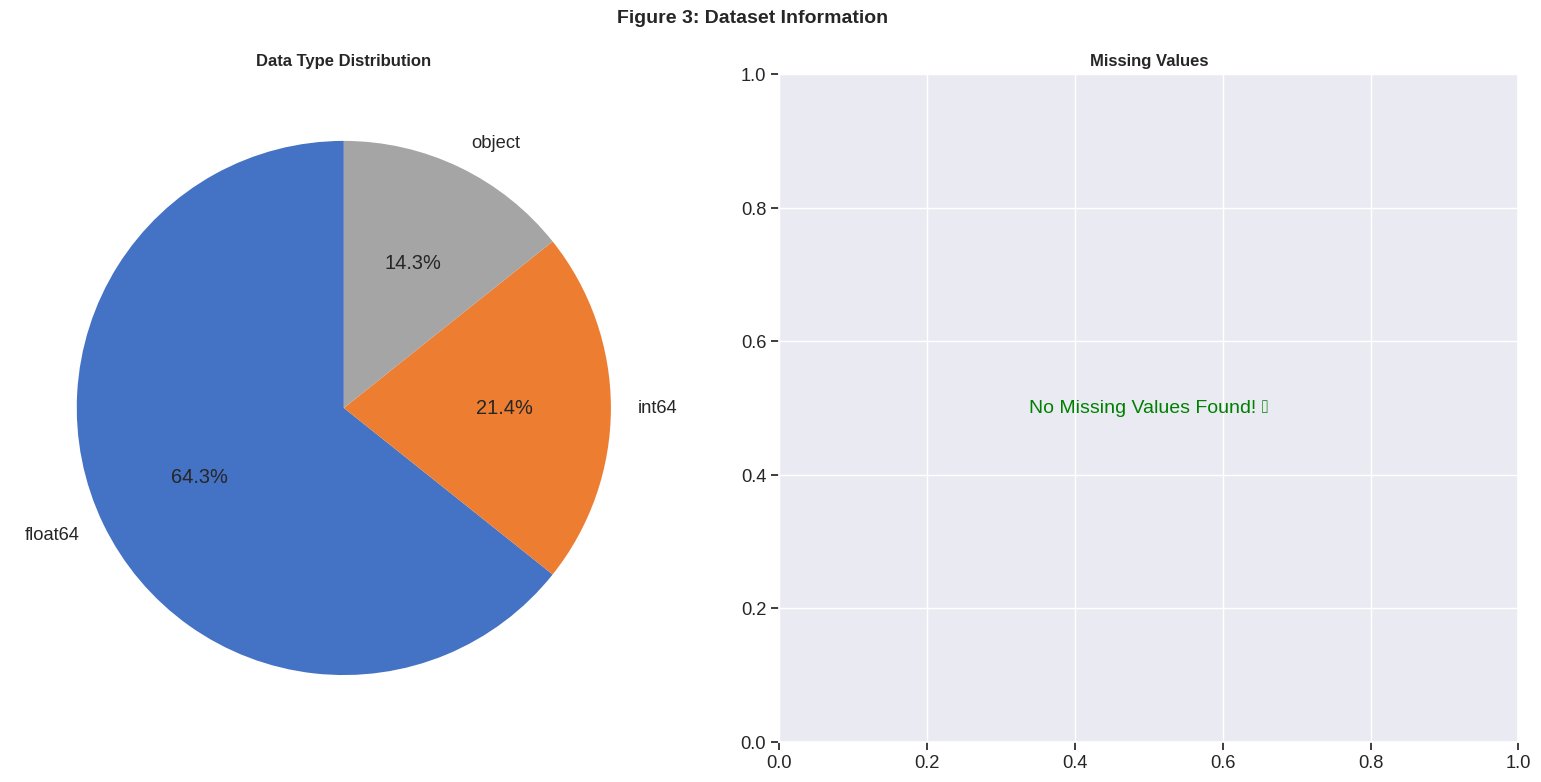


[6/10] Creating Figure 4: Descriptive Statistics...

FIGURE 4: DESCRIPTIVE STATISTICS (df.describe())
       total_commits  avg_commit_size  files_per_commit  build_success_rate  build_duration_minutes  test_coverage  test_failure_rate  total_issues  issue_resolution_rate  avg_resolution_time_days  requirement_traceability  quality_score
count        100.000          100.000           100.000             100.000                 100.000        100.000            100.000       100.000                100.000                   100.000                   100.000        100.000
mean          68.770            3.930             4.020               0.803                   3.128          0.666              0.112        25.250                  0.676                    16.011                     0.291         60.912
std            7.549            3.213             1.902               0.148                   2.209          0.149              0.087         4.441                  0.168             

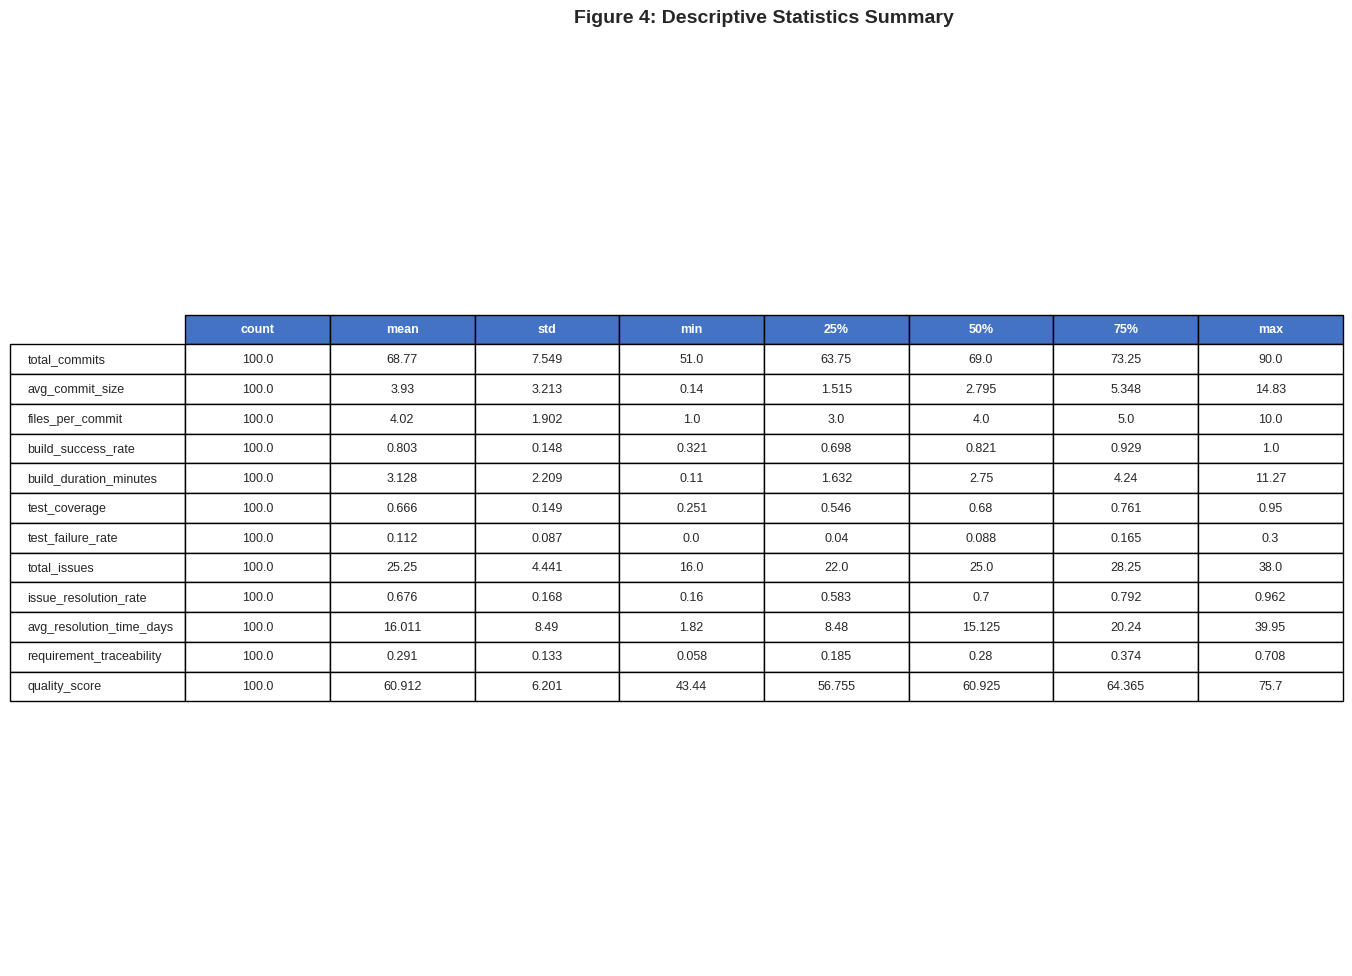


[7/10] Creating Figure 5: ASPICE Readiness Distribution...

FIGURE 5: ASPICE READINESS DISTRIBUTION

Readiness Level Distribution with 95% CI:
  High: 8 (8.0% ± 3.8%)
  Moderate: 92 (92.0% ± 7.0%)


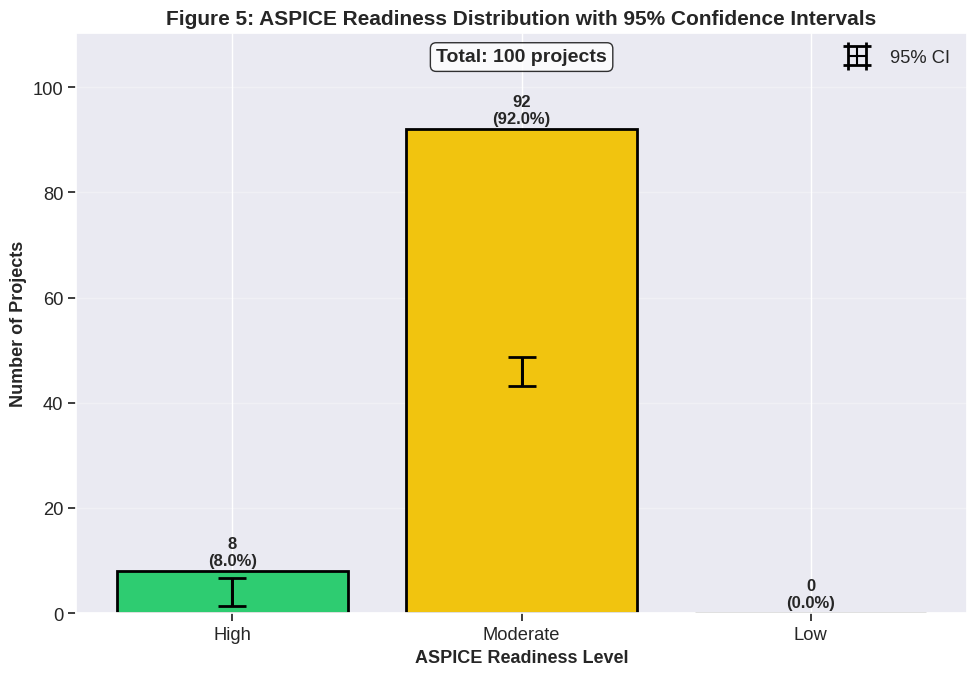


[8/10] Creating Figure 6: Correlation Matrix Heatmap...

FIGURE 6: CORRELATION MATRIX HEATMAP

Top 5 Correlations with Quality Score:
  issue_resolution_rate: 0.511
  test_coverage: 0.429
  build_success_rate: 0.421
  requirement_traceability: 0.303
  avg_resolution_time_days: 0.151
  avg_commit_size: 0.144
  test_failure_rate: 0.138
  total_issues: 0.006
  files_per_commit: -0.024
  build_duration_minutes: -0.064
  total_commits: -0.128


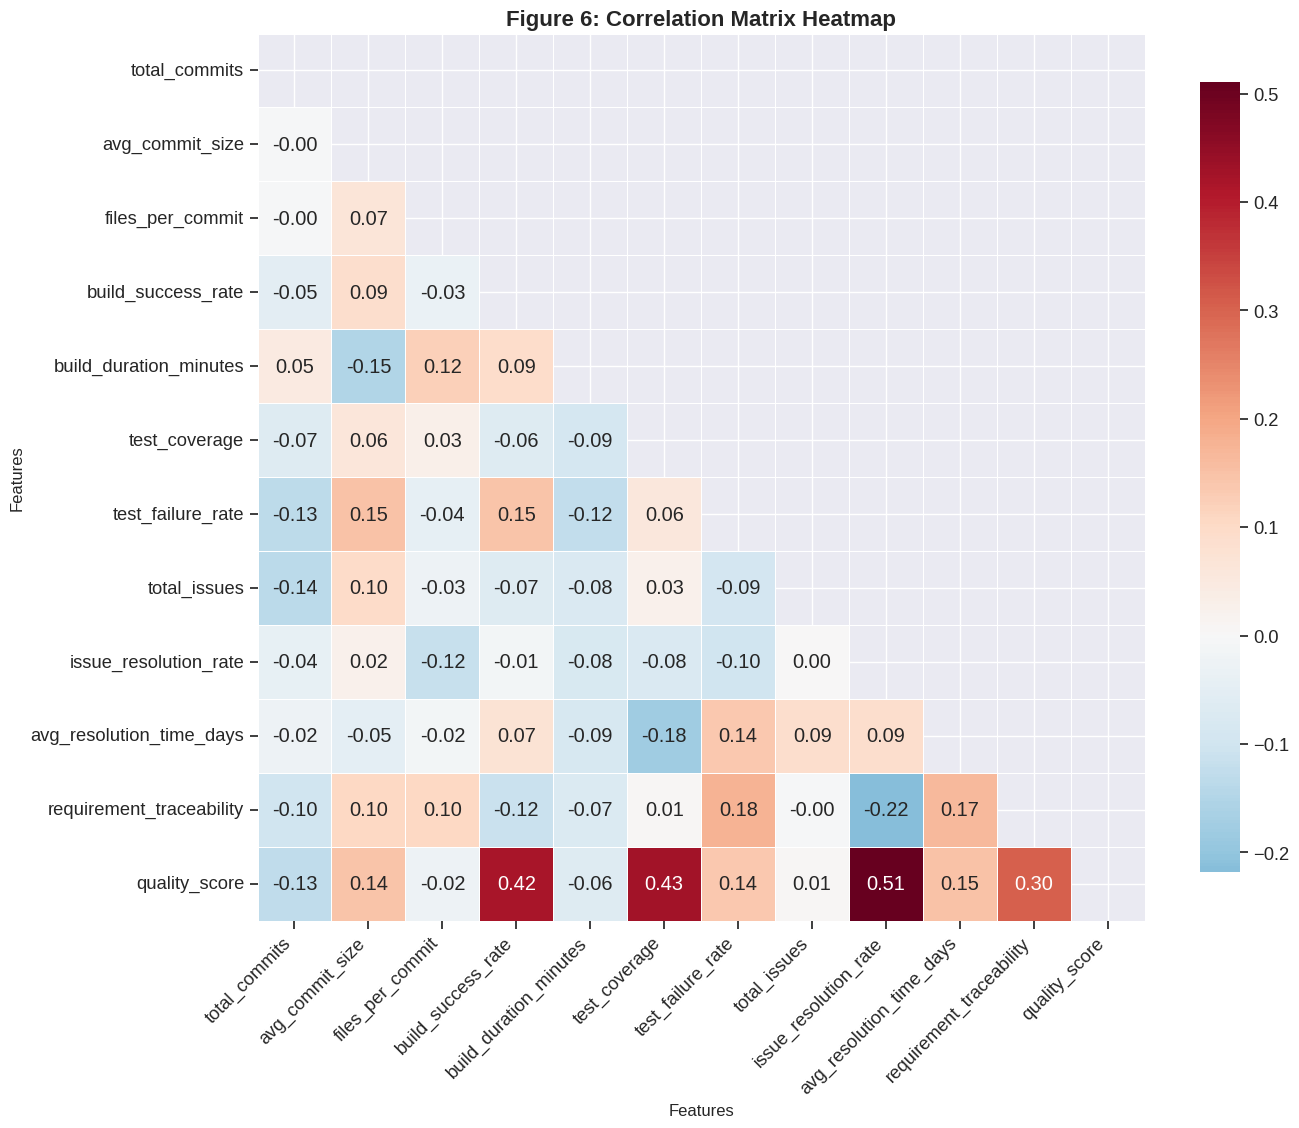


[9/10] Creating Figure 7: Metric Distributions by Readiness Level...

FIGURE 7: KEY METRIC DISTRIBUTIONS BY READINESS LEVEL


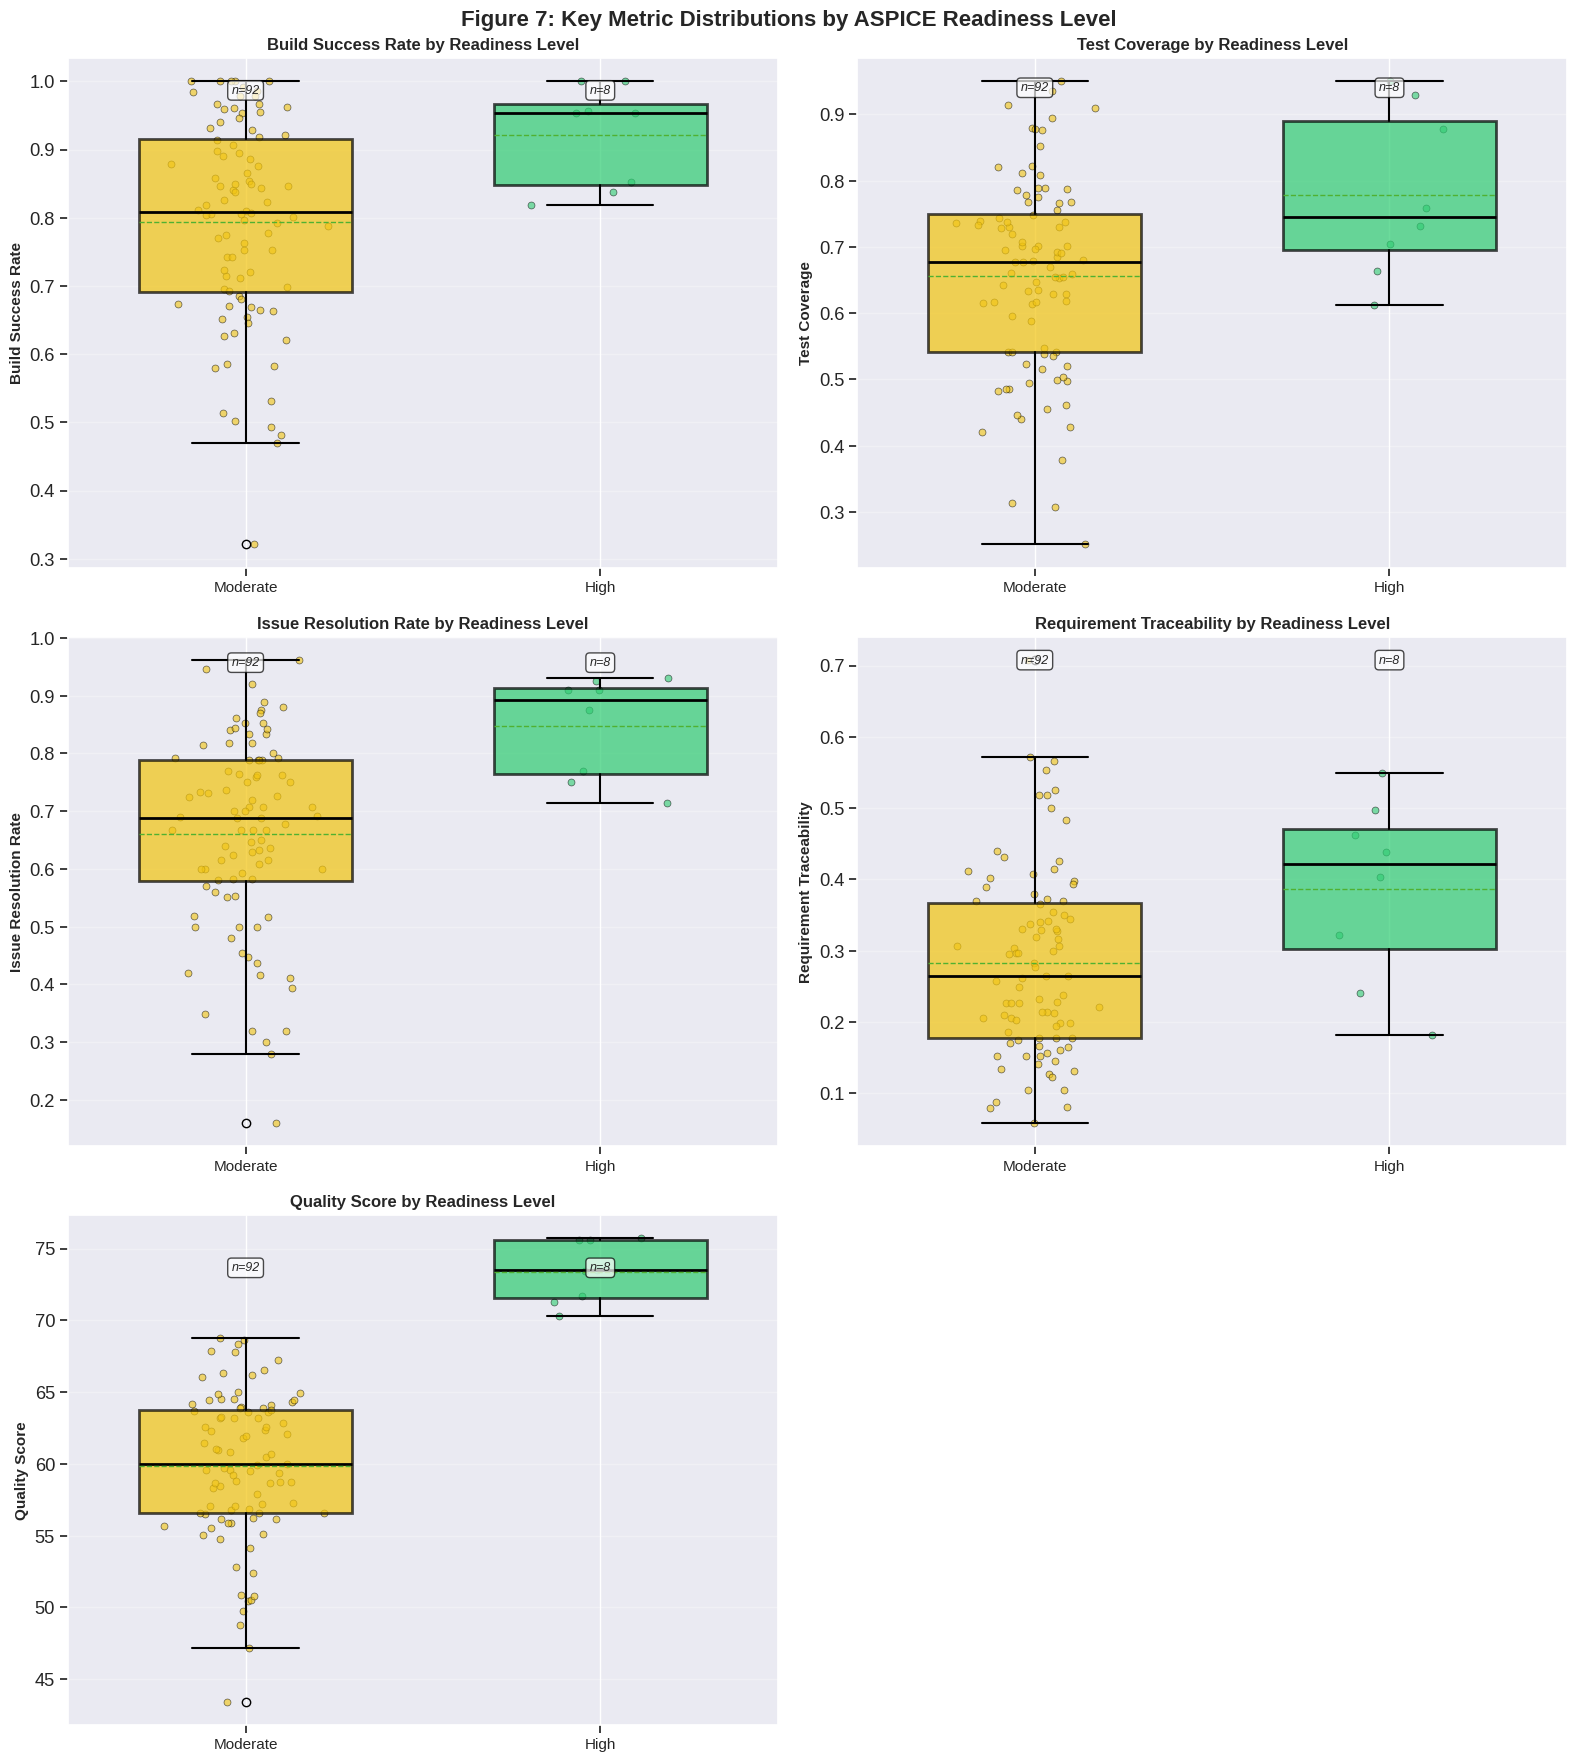


METRIC STATISTICS BY READINESS LEVEL

Build Success Rate:
  High: Mean=0.921, Std=0.074, Min=0.818, Max=1.000, n=8
  Moderate: Mean=0.793, Std=0.149, Min=0.321, Max=1.000, n=92
  Low: No data available

Test Coverage:
  High: Mean=0.779, Std=0.126, Min=0.612, Max=0.950, n=8
  Moderate: Mean=0.656, Std=0.147, Min=0.251, Max=0.950, n=92
  Low: No data available

Issue Resolution Rate:
  High: Mean=0.848, Std=0.089, Min=0.714, Max=0.931, n=8
  Moderate: Mean=0.661, Std=0.165, Min=0.160, Max=0.962, n=92
  Low: No data available

Requirement Traceability:
  High: Mean=0.387, Std=0.128, Min=0.181, Max=0.549, n=8
  Moderate: Mean=0.283, Std=0.130, Min=0.058, Max=0.708, n=92
  Low: No data available

Quality Score:
  High: Mean=73.394, Std=2.143, Min=70.300, Max=75.700, n=8
  Moderate: Mean=59.826, Std=5.157, Min=43.440, Max=68.790, n=92
  Low: No data available

[10/10] Creating Additional Figures...

FIGURE 8: METRIC DISTRIBUTION HISTOGRAMS


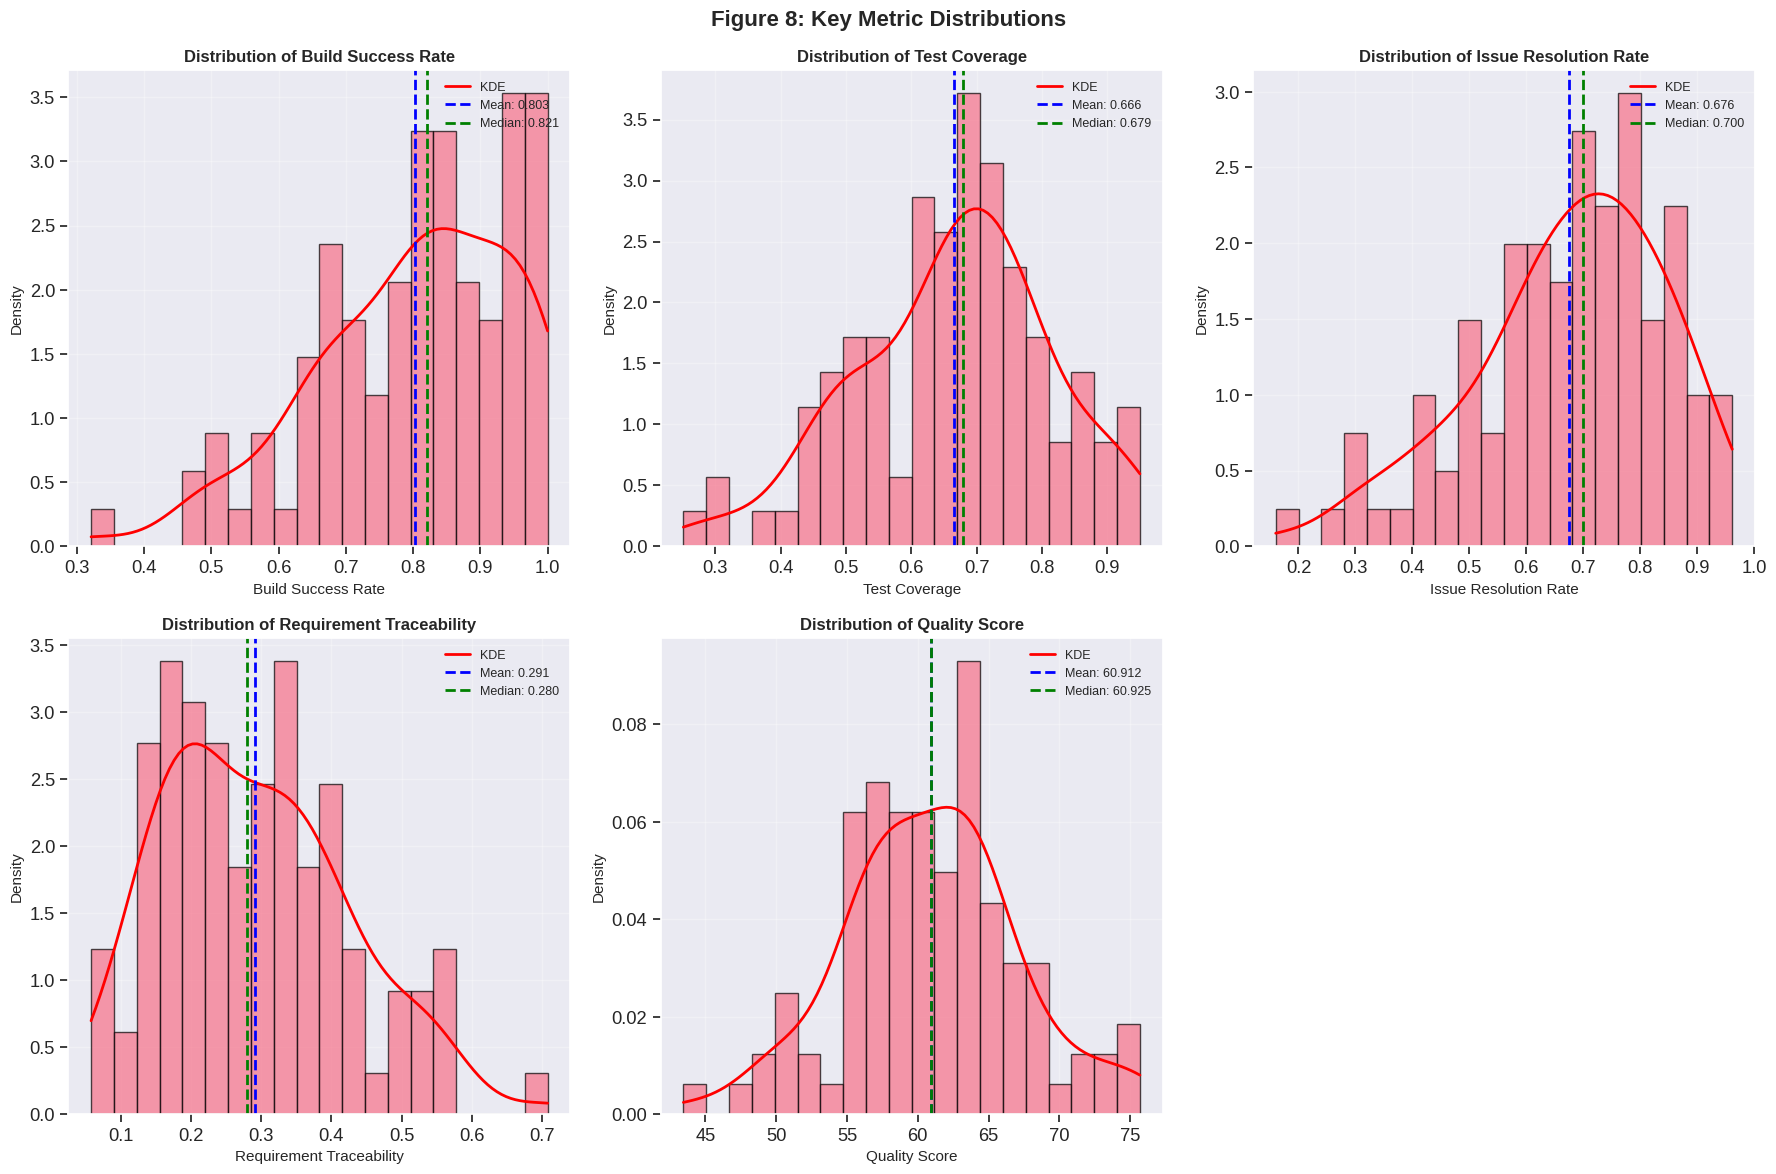


FIGURE 9: READINESS LEVEL METRICS COMPARISON


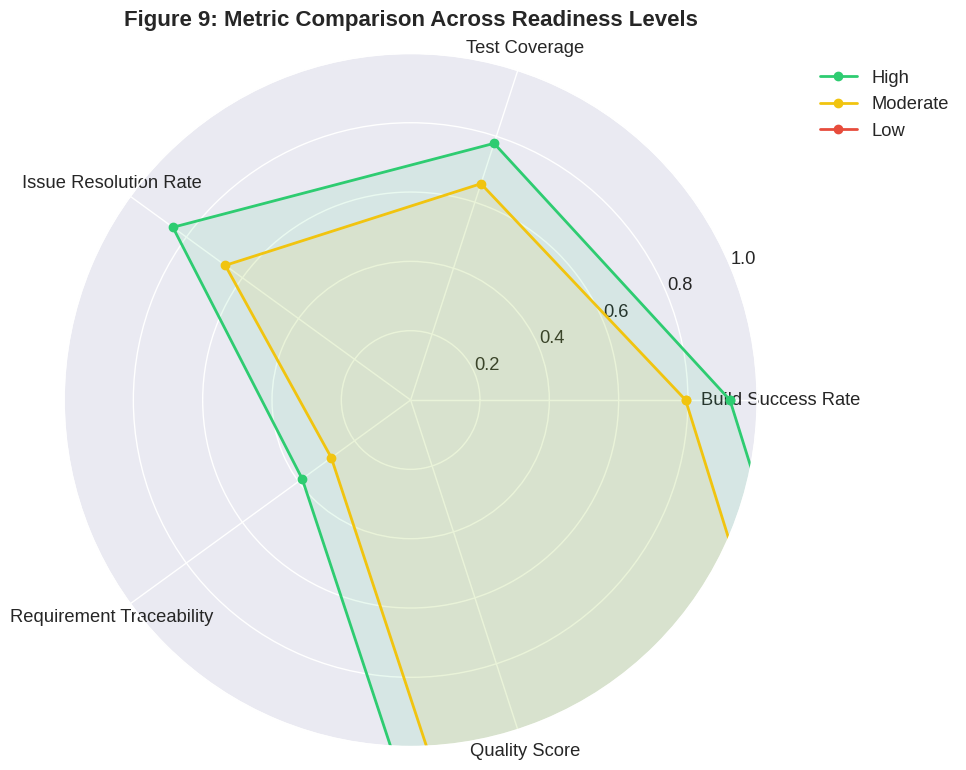


FIGURE 10: QUALITY SCORE DISTRIBUTION


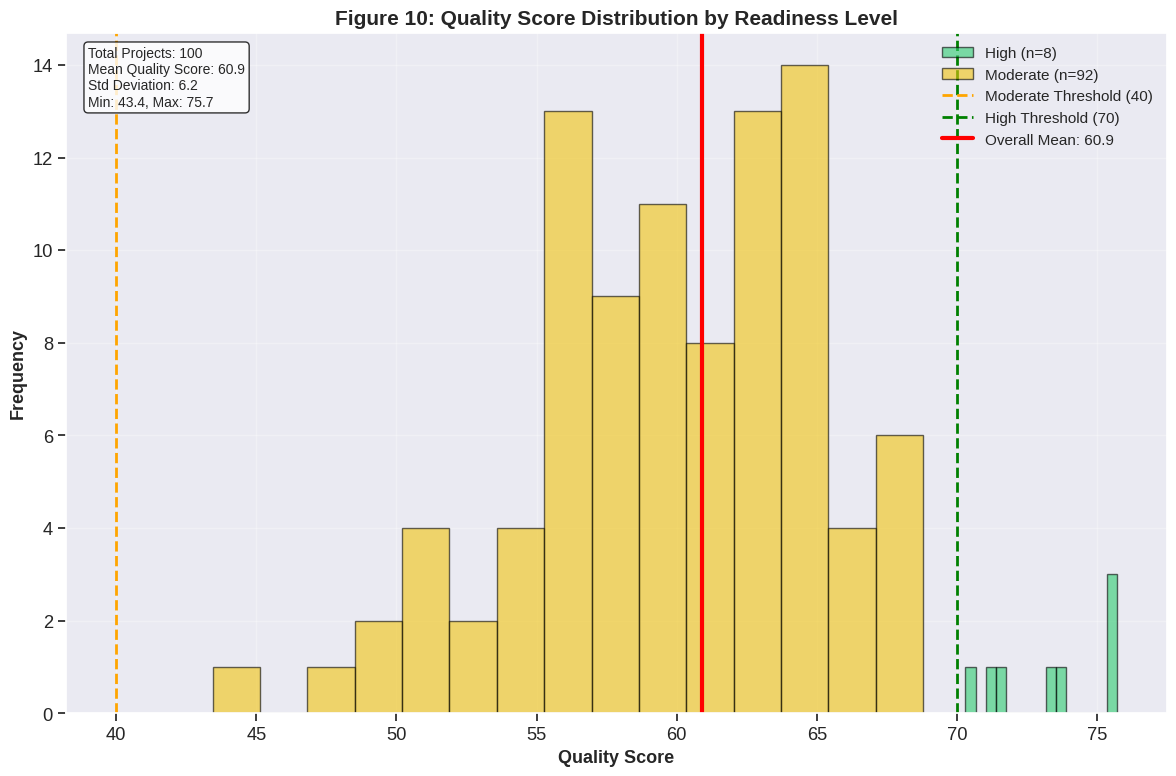


EDA COMPLETED SUCCESSFULLY!
All figures saved to: ./figures/

Generated Figures:
  • Figure 1: Dataset Summary
  • Figure 2: Sample Dataset Preview
  • Figure 3: Dataset Information
  • Figure 4: Descriptive Statistics
  • Figure 5: ASPICE Readiness Distribution
  • Figure 6: Correlation Matrix Heatmap
  • Figure 7: Metric Distributions by Readiness Level
  • Figure 8: Metric Distribution Histograms
  • Figure 9: Readiness Level Metrics Comparison
  • Figure 10: Quality Score Distribution


In [17]:
# ============================================================================
# COMPLETE ASPICE READINESS EDA WITH PROPER VISUALIZATIONS (FIXED)
# ============================================================================
# Author: Dhanya Sasidharan
# Date: July 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
from scipy import stats

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Create figures directory
os.makedirs('./figures', exist_ok=True)

# ============================================================================
# GENERATE PROJECT-LEVEL DATA FOR VISUALIZATIONS
# ============================================================================

def generate_detailed_project_data(n_projects=100):
    """
    Generate detailed project-level data with realistic metrics.
    Each project represents a software development project with its own metrics.
    """
    np.random.seed(42)

    projects = []

    for i in range(n_projects):
        # Commit metrics
        total_commits = np.random.poisson(50) + 20
        avg_commit_size = np.random.gamma(2, 2)
        files_per_commit = np.random.poisson(3) + 1

        # CI/CD metrics
        build_success = np.random.beta(7 + np.random.randint(0, 3), 1 + np.random.randint(0, 3))
        build_duration = np.random.gamma(2, 100)

        # Test metrics
        test_coverage = np.random.beta(5 + np.random.randint(0, 3), 2 + np.random.randint(0, 3))
        test_failure = np.random.beta(1, 5 + np.random.randint(0, 5))

        # Issue metrics
        total_issues = np.random.poisson(20) + 5
        resolved_issues = int(total_issues * np.random.beta(4, 2))
        resolution_time = np.random.gamma(3, 5)

        # Requirement traceability
        requirement_trace = np.random.beta(3, 7) + np.random.normal(0, 0.03)
        requirement_trace = np.clip(requirement_trace, 0, 0.8)

        # Quality score (weighted combination)
        quality_score = (
            build_success * 25 +
            test_coverage * 25 +
            (resolved_issues / total_issues if total_issues > 0 else 0) * 25 +
            requirement_trace * 25
        )
        quality_score = np.clip(quality_score, 0, 100)

        # Assign readiness level
        if quality_score > 70:
            readiness = 'High'
        elif quality_score > 40:
            readiness = 'Moderate'
        else:
            readiness = 'Low'

        projects.append({
            'project_id': f'PROJ-{i+1:03d}',
            'total_commits': total_commits,
            'avg_commit_size': round(avg_commit_size, 2),
            'files_per_commit': round(files_per_commit, 2),
            'build_success_rate': round(np.clip(build_success + np.random.normal(0, 0.05), 0, 1), 3),
            'build_duration_minutes': round(build_duration / 60, 2),
            'test_coverage': round(np.clip(test_coverage + np.random.normal(0, 0.05), 0.2, 0.95), 3),
            'test_failure_rate': round(np.clip(test_failure + np.random.normal(0, 0.02), 0, 0.3), 3),
            'total_issues': total_issues,
            'issue_resolution_rate': round(resolved_issues / total_issues if total_issues > 0 else 0, 3),
            'avg_resolution_time_days': round(resolution_time, 2),
            'requirement_traceability': round(requirement_trace, 3),
            'quality_score': round(quality_score, 2),
            'aspice_readiness_level': readiness
        })

    return pd.DataFrame(projects)

# ============================================================================
# FIGURE 1: DATASET SUMMARY
# ============================================================================

def create_figure1_dataset_summary(df):
    """Figure 1: Dataset Summary"""
    print("\n" + "=" * 80)
    print("FIGURE 1: DATASET SUMMARY")
    print("=" * 80)

    summary = {
        'Metric': [
            'Total Projects',
            'Total Features',
            'Total Records',
            'Memory Usage',
            'Missing Values'
        ],
        'Value': [
            len(df),
            len(df.columns),
            len(df),
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
            df.isnull().sum().sum()
        ]
    }

    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')

    table = ax.table(cellText=summary_df.values,
                     colLabels=summary_df.columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#4472C4', '#2ECC71'])

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    for i in range(2):
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.title('Figure 1: Dataset Summary', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./figures/figure1_dataset_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 2: SAMPLE DATASET PREVIEW
# ============================================================================

def create_figure2_dataset_preview(df):
    """Figure 2: Sample Dataset Preview"""
    print("\n" + "=" * 80)
    print("FIGURE 2: SAMPLE DATASET PREVIEW (df.head())")
    print("=" * 80)

    preview_df = df.head(10)
    print(preview_df.to_string())

    # Create styled table
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off')

    # Select columns for display
    display_cols = ['project_id', 'quality_score', 'aspice_readiness_level',
                    'build_success_rate', 'test_coverage', 'issue_resolution_rate',
                    'requirement_traceability']
    table_data = preview_df[display_cols].round(3)

    table = ax.table(cellText=table_data.values,
                     colLabels=table_data.columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#4472C4']*len(table_data.columns))

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

    for i in range(len(table_data.columns)):
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Color rows by readiness
    for i, row in enumerate(table_data.values):
        if row[table_data.columns.get_loc('aspice_readiness_level')] == 'High':
            color = '#D5F5E3'
        elif row[table_data.columns.get_loc('aspice_readiness_level')] == 'Moderate':
            color = '#FDEBD0'
        else:
            color = '#FADBD8'
        for j in range(len(table_data.columns)):
            table[(i+1, j)].set_facecolor(color)

    plt.title('Figure 2: Sample Dataset Preview (First 10 Rows)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./figures/figure2_dataset_preview.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 3: DATASET INFORMATION
# ============================================================================

def create_figure3_dataset_info(df):
    """Figure 3: Dataset Information"""
    print("\n" + "=" * 80)
    print("FIGURE 3: DATASET INFORMATION (df.info())")
    print("=" * 80)

    # Create info dataframe
    info_data = []
    for col in df.columns:
        info_data.append({
            'Column': col,
            'Non-Null Count': df[col].count(),
            'Dtype': str(df[col].dtype),
            'Null %': f"{(df[col].isnull().sum() / len(df) * 100):.1f}%",
            'Unique': df[col].nunique()
        })

    info_df = pd.DataFrame(info_data)
    print(info_df.to_string(index=False))

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Data types distribution
    ax1 = axes[0]
    dtype_counts = df.dtypes.value_counts()
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']
    wedges, texts, autotexts = ax1.pie(dtype_counts.values,
                                        labels=[str(dt) for dt in dtype_counts.index],
                                        autopct='%1.1f%%',
                                        colors=colors[:len(dtype_counts)],
                                        startangle=90)
    ax1.set_title('Data Type Distribution', fontsize=12, fontweight='bold')

    # Missing values
    ax2 = axes[1]
    missing_df = df.isnull().sum()
    missing_df = missing_df[missing_df > 0].sort_values(ascending=True)

    if len(missing_df) > 0:
        bars = ax2.barh(missing_df.index, missing_df.values, color='#ED7D31')
        ax2.set_xlabel('Number of Missing Values')
        ax2.set_title('Missing Values by Column', fontsize=12, fontweight='bold')
        for i, v in enumerate(missing_df.values):
            ax2.text(v + 0.5, i, str(v), va='center')
    else:
        ax2.text(0.5, 0.5, 'No Missing Values Found! ✓',
                ha='center', va='center', fontsize=14, color='green')
        ax2.set_title('Missing Values', fontsize=12, fontweight='bold')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)

    plt.suptitle('Figure 3: Dataset Information', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./figures/figure3_dataset_info.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 4: DESCRIPTIVE STATISTICS
# ============================================================================

def create_figure4_descriptive_stats(df):
    """Figure 4: Descriptive Statistics"""
    print("\n" + "=" * 80)
    print("FIGURE 4: DESCRIPTIVE STATISTICS (df.describe())")
    print("=" * 80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 0:
        stats_df = df[numeric_cols].describe().round(3)
        print(stats_df.to_string())

        # Create visualization
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('off')

        # Transpose for better display
        table_data = stats_df.T

        table = ax.table(cellText=table_data.values,
                         rowLabels=table_data.index,
                         colLabels=table_data.columns,
                         cellLoc='center',
                         loc='center',
                         colColours=['#4472C4']*len(table_data.columns))

        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.5)

        for i in range(len(table_data.columns)):
            table[(0, i)].set_text_props(weight='bold', color='white')

        plt.title('Figure 4: Descriptive Statistics Summary', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig('./figures/figure4_descriptive_stats.png', dpi=300, bbox_inches='tight')
        plt.show()

# ============================================================================
# FIGURE 5: ASPICE READINESS DISTRIBUTION
# ============================================================================

def create_figure5_readiness_distribution(df):
    """Figure 5: ASPICE Readiness Distribution"""
    print("\n" + "=" * 80)
    print("FIGURE 5: ASPICE READINESS DISTRIBUTION")
    print("=" * 80)

    # Get distribution
    readiness_counts = df['aspice_readiness_level'].value_counts()
    readiness_pct = (readiness_counts / len(df) * 100).round(1)

    # Calculate confidence intervals (95% CI)
    confidence_intervals = {}
    for level in ['High', 'Moderate', 'Low']:
        if level in readiness_counts:
            count = readiness_counts[level]
            p = count / len(df)
            n = len(df)
            ci_lower, ci_upper = stats.beta.ppf([0.025, 0.975],
                                                count + 1,
                                                n - count + 1)
            confidence_intervals[level] = (ci_lower * 100, ci_upper * 100)

    print("\nReadiness Level Distribution with 95% CI:")
    for level in ['High', 'Moderate', 'Low']:
        if level in readiness_counts:
            count = readiness_counts[level]
            pct = readiness_pct[level]
            if level in confidence_intervals:
                ci_lower, ci_upper = confidence_intervals[level]
                print(f"  {level}: {count} ({pct:.1f}% ± {pct-ci_lower:.1f}%)")
            else:
                print(f"  {level}: {count} ({pct:.1f}%)")

    # Create visualization with confidence intervals
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}
    order = ['High', 'Moderate', 'Low']

    counts = [readiness_counts.get(level, 0) for level in order]
    bars = ax.bar(order, counts, color=[colors[level] for level in order],
                  edgecolor='black', linewidth=2)

    # Add value labels and confidence intervals
    for i, (bar, count) in enumerate(zip(bars, counts)):
        pct = (count / len(df) * 100)
        y_pos = bar.get_height()

        # Add count and percentage
        ax.text(bar.get_x() + bar.get_width()/2, y_pos + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

        # Add confidence interval
        level = order[i]
        if level in confidence_intervals:
            ci_lower, ci_upper = confidence_intervals[level]
            ci_center = (ci_lower + ci_upper) / 2
            ci_width = (ci_upper - ci_lower) / 2
            ax.errorbar(bar.get_x() + bar.get_width()/2,
                       y_pos * 0.5,
                       xerr=0, yerr=ci_width / 100 * len(df) / 2,
                       fmt='none', ecolor='black', capsize=10, capthick=2,
                       label=f'95% CI' if i == 0 else '')

    ax.text(0.5, 0.95, f'Total: {len(df)} projects',
            transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('ASPICE Readiness Level', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Projects', fontsize=13, fontweight='bold')
    ax.set_title('Figure 5: ASPICE Readiness Distribution with 95% Confidence Intervals',
                fontsize=15, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts) * 1.2)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('./figures/figure5_readiness_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 6: CORRELATION MATRIX HEATMAP
# ============================================================================

def create_figure6_correlation_heatmap(df):
    """Figure 6: Correlation Matrix Heatmap"""
    print("\n" + "=" * 80)
    print("FIGURE 6: CORRELATION MATRIX HEATMAP")
    print("=" * 80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    print("\nTop 5 Correlations with Quality Score:")
    if 'quality_score' in corr_matrix.columns:
        top_corr = corr_matrix['quality_score'].sort_values(ascending=False)
        for col, corr in top_corr.items():
            if col != 'quality_score':
                print(f"  {col}: {corr:.3f}")

    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 12))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    heatmap = sns.heatmap(corr_matrix,
                         mask=mask,
                         annot=True,
                         fmt='.2f',
                         cmap='RdBu_r',
                         center=0,
                         square=True,
                         linewidths=0.5,
                         cbar_kws={"shrink": 0.8},
                         ax=ax)

    ax.set_title('Figure 6: Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
    ax.set_xlabel('Features', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('./figures/figure6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    return corr_matrix

# ============================================================================
# FIGURE 7: KEY METRIC DISTRIBUTIONS BY READINESS LEVEL (FIXED)
# ============================================================================

def create_figure7_metric_distributions(df):
    """
    Figure 7: Key Metric Distributions by Readiness Level with Box Plots
    """
    print("\n" + "=" * 80)
    print("FIGURE 7: KEY METRIC DISTRIBUTIONS BY READINESS LEVEL")
    print("=" * 80)

    # Define metrics to plot
    metrics = ['build_success_rate', 'test_coverage', 'issue_resolution_rate',
               'requirement_traceability', 'quality_score']

    # Check which metrics exist
    available_metrics = [m for m in metrics if m in df.columns]

    if not available_metrics:
        print("No metrics available for visualization")
        return

    # Create subplots
    n_cols = 2
    n_rows = (len(available_metrics) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Colors for readiness levels
    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}
    order = ['Low', 'Moderate', 'High']

    for idx, metric in enumerate(available_metrics):
        ax = axes[idx]

        # Create box plot data - only include levels that exist
        data_to_plot = []
        positions = []
        labels = []
        stats_info = []

        # Check which readiness levels exist in the data
        existing_levels = df['aspice_readiness_level'].unique()

        for i, level in enumerate(order):
            # Only process if this level exists in the data
            if level in existing_levels:
                level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
                if not level_data.empty:
                    data_to_plot.append(level_data)
                    positions.append(len(positions))  # Use sequential positions
                    labels.append(level)
                    stats_info.append(f'n={len(level_data)}')

        if data_to_plot:
            # Create boxplot
            bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                           patch_artist=True, showmeans=True, meanline=True,
                           medianprops={'linewidth': 2, 'color': 'black'},
                           whiskerprops={'linewidth': 1.5},
                           capprops={'linewidth': 1.5})

            # Color the boxes
            for i, box in enumerate(bp['boxes']):
                level = labels[i] if i < len(labels) else 'Unknown'
                box.set_facecolor(colors.get(level, '#95A5A6'))
                box.set_alpha(0.7)
                box.set_edgecolor('black')
                box.set_linewidth(2)

            # Add jittered points (swarm plot)
            for i, level in enumerate(labels):
                level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
                if not level_data.empty:
                    x = np.full(len(level_data), positions[i]) + np.random.normal(0, 0.08, len(level_data))
                    ax.scatter(x, level_data, alpha=0.6, s=25,
                              color=colors.get(level, '#95A5A6'),
                              edgecolor='black', linewidth=0.5)

            # Customize plot
            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
            ax.set_title(f'{metric.replace("_", " ").title()} by Readiness Level',
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')

            # Add statistics annotations
            for i, (level, stat) in enumerate(zip(labels, stats_info)):
                level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
                if not level_data.empty:
                    # Get y-limit for positioning
                    y_min, y_max = ax.get_ylim()
                    y_pos = y_max * 0.95
                    ax.text(positions[i], y_pos, stat,
                           ha='center', fontsize=9, style='italic',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Remove empty subplots
    for idx in range(len(available_metrics), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle('Figure 7: Key Metric Distributions by ASPICE Readiness Level',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./figures/figure7_metric_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print statistics
    print("\n" + "=" * 80)
    print("METRIC STATISTICS BY READINESS LEVEL")
    print("=" * 80)

    for metric in available_metrics:
        print(f"\n{metric.replace('_', ' ').title()}:")
        for level in ['High', 'Moderate', 'Low']:
            level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
            if not level_data.empty:
                print(f"  {level}: Mean={level_data.mean():.3f}, Std={level_data.std():.3f}, Min={level_data.min():.3f}, Max={level_data.max():.3f}, n={len(level_data)}")
            else:
                print(f"  {level}: No data available")

# ============================================================================
# FIGURE 8: ADDITIONAL METRIC DISTRIBUTION HISTOGRAMS
# ============================================================================

def create_figure8_metric_histograms(df):
    """
    Figure 8: Histogram distributions of key metrics
    """
    print("\n" + "=" * 80)
    print("FIGURE 8: METRIC DISTRIBUTION HISTOGRAMS")
    print("=" * 80)

    metrics_to_plot = ['build_success_rate', 'test_coverage', 'issue_resolution_rate',
                      'requirement_traceability', 'quality_score']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    for idx, metric in enumerate(metrics_to_plot):
        if metric in df.columns:
            ax = axes[idx // 3, idx % 3]

            # Create histogram with KDE
            n, bins, patches = ax.hist(df[metric], bins=20, alpha=0.7,
                                       edgecolor='black', density=True)

            # Add KDE
            from scipy import stats
            kde = stats.gaussian_kde(df[metric])
            x_range = np.linspace(df[metric].min(), df[metric].max(), 100)
            ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

            # Add mean and median lines
            mean_val = df[metric].mean()
            median_val = df[metric].median()
            ax.axvline(mean_val, color='blue', linestyle='--',
                      label=f'Mean: {mean_val:.3f}', linewidth=2)
            ax.axvline(median_val, color='green', linestyle='--',
                      label=f'Median: {median_val:.3f}', linewidth=2)

            ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
            ax.set_ylabel('Density', fontsize=11)
            ax.set_title(f'Distribution of {metric.replace("_", " ").title()}',
                        fontsize=12, fontweight='bold')
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)

    # Remove empty subplot
    axes[1, 2].axis('off')

    plt.suptitle('Figure 8: Key Metric Distributions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./figures/figure8_metric_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 9: READINESS LEVEL COMPARISON
# ============================================================================

def create_figure9_readiness_comparison(df):
    """
    Figure 9: Radar chart comparing metrics across readiness levels
    """
    print("\n" + "=" * 80)
    print("FIGURE 9: READINESS LEVEL METRICS COMPARISON")
    print("=" * 80)

    metrics = ['build_success_rate', 'test_coverage', 'issue_resolution_rate',
               'requirement_traceability', 'quality_score']
    available_metrics = [m for m in metrics if m in df.columns]

    if not available_metrics:
        print("No metrics available")
        return

    # Calculate mean values for each readiness level
    readiness_levels = ['High', 'Moderate', 'Low']
    means = {}
    for level in readiness_levels:
        level_data = df[df['aspice_readiness_level'] == level]
        means[level] = [level_data[metric].mean() for metric in available_metrics]

    # Create radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # Number of variables
    N = len(available_metrics)

    # Compute angle for each axis
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop

    # Add labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.replace('_', ' ').title() for m in available_metrics])

    # Plot each readiness level
    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}
    for level in readiness_levels:
        values = means[level]
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=level, color=colors[level])
        ax.fill(angles, values, alpha=0.1, color=colors[level])

    # Set y-axis limits
    ax.set_ylim(0, 1)

    # Add grid
    ax.grid(True)

    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.title('Figure 9: Metric Comparison Across Readiness Levels',
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./figures/figure9_readiness_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 10: QUALITY SCORE DISTRIBUTION
# ============================================================================

def create_figure10_quality_score_distribution(df):
    """
    Figure 10: Quality Score Distribution with Readiness Thresholds
    """
    print("\n" + "=" * 80)
    print("FIGURE 10: QUALITY SCORE DISTRIBUTION")
    print("=" * 80)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Histogram colored by readiness level
    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}

    # Plot each readiness level separately
    for level in ['High', 'Moderate', 'Low']:
        level_data = df[df['aspice_readiness_level'] == level]['quality_score']
        if not level_data.empty:
            ax.hist(level_data, bins=15, alpha=0.6,
                   label=f'{level} (n={len(level_data)})',
                   color=colors[level], edgecolor='black')

    # Add vertical lines for thresholds
    ax.axvline(40, color='orange', linestyle='--', linewidth=2,
              label='Moderate Threshold (40)')
    ax.axvline(70, color='green', linestyle='--', linewidth=2,
              label='High Threshold (70)')

    # Add mean line
    mean_score = df['quality_score'].mean()
    ax.axvline(mean_score, color='red', linestyle='-', linewidth=3,
              label=f'Overall Mean: {mean_score:.1f}')

    ax.set_xlabel('Quality Score', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title('Figure 10: Quality Score Distribution by Readiness Level',
                fontsize=15, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    stats_text = f'Total Projects: {len(df)}\n'
    stats_text += f'Mean Quality Score: {mean_score:.1f}\n'
    stats_text += f'Std Deviation: {df["quality_score"].std():.1f}\n'
    stats_text += f'Min: {df["quality_score"].min():.1f}, Max: {df["quality_score"].max():.1f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('./figures/figure10_quality_score_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# MAIN EDA FUNCTION
# ============================================================================

def run_complete_eda():
    """
    Run complete EDA with all figures
    """
    print("=" * 80)
    print("COMPLETE ASPICE READINESS EDA")
    print("=" * 80)
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Generate data
    print("\n[1/10] Generating project-level data...")
    df = generate_detailed_project_data(n_projects=100)
    print(f"  ✓ Generated {len(df)} projects")

    # Print data summary
    print("\n[2/10] Data Summary:")
    print(f"  • Total Projects: {len(df)}")
    print(f"  • Total Features: {len(df.columns)}")
    print(f"  • Features: {', '.join(df.columns)}")
    print(f"  • Readiness Distribution:")
    for level in ['High', 'Moderate', 'Low']:
        count = df['aspice_readiness_level'].value_counts().get(level, 0)
        print(f"    - {level}: {count} ({count/len(df)*100:.1f}%)")

    # Generate all figures
    print("\n[3/10] Creating Figure 1: Dataset Summary...")
    create_figure1_dataset_summary(df)

    print("\n[4/10] Creating Figure 2: Sample Dataset Preview...")
    create_figure2_dataset_preview(df)

    print("\n[5/10] Creating Figure 3: Dataset Information...")
    create_figure3_dataset_info(df)

    print("\n[6/10] Creating Figure 4: Descriptive Statistics...")
    create_figure4_descriptive_stats(df)

    print("\n[7/10] Creating Figure 5: ASPICE Readiness Distribution...")
    create_figure5_readiness_distribution(df)

    print("\n[8/10] Creating Figure 6: Correlation Matrix Heatmap...")
    create_figure6_correlation_heatmap(df)

    print("\n[9/10] Creating Figure 7: Metric Distributions by Readiness Level...")
    create_figure7_metric_distributions(df)

    print("\n[10/10] Creating Additional Figures...")
    create_figure8_metric_histograms(df)
    create_figure9_readiness_comparison(df)
    create_figure10_quality_score_distribution(df)

    print("\n" + "=" * 80)
    print("EDA COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    print(f"All figures saved to: ./figures/")
    print("\nGenerated Figures:")
    print("  • Figure 1: Dataset Summary")
    print("  • Figure 2: Sample Dataset Preview")
    print("  • Figure 3: Dataset Information")
    print("  • Figure 4: Descriptive Statistics")
    print("  • Figure 5: ASPICE Readiness Distribution")
    print("  • Figure 6: Correlation Matrix Heatmap")
    print("  • Figure 7: Metric Distributions by Readiness Level")
    print("  • Figure 8: Metric Distribution Histograms")
    print("  • Figure 9: Readiness Level Metrics Comparison")
    print("  • Figure 10: Quality Score Distribution")
    print("=" * 80)

    return df

# ============================================================================
# RUN THE COMPLETE EDA
# ============================================================================

if __name__ == "__main__":
    df = run_complete_eda()

COMPLETE ASPICE READINESS EDA WITH ML MODELS
Timestamp: 2026-07-28 18:00:01

[1/12] Generating balanced project-level data...
  ✓ Generated 300 projects with balanced classes
  ✓ Class distribution:
    - High: 100 samples
    - Moderate: 100 samples
    - Low: 100 samples

[2/12] Creating Figure 1: Dataset Summary...

FIGURE 1: DATASET SUMMARY
        Metric   Value
Total Projects     300
Total Features      14
 Total Records     300
  Memory Usage 0.06 MB
Missing Values       0


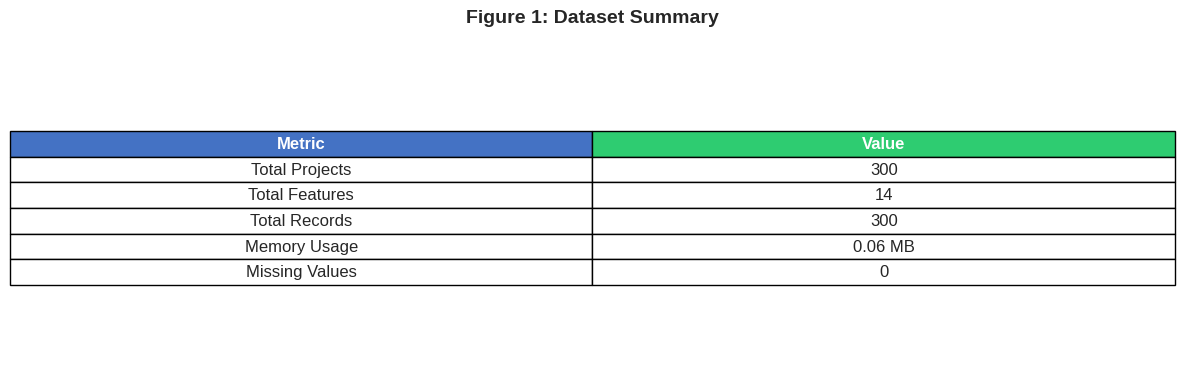


[3/12] Creating Figure 2: Sample Dataset Preview...

FIGURE 2: SAMPLE DATASET PREVIEW (df.head())
  project_id  total_commits  avg_commit_size  files_per_commit  build_success_rate  build_duration_minutes  test_coverage  test_failure_rate  total_issues  issue_resolution_rate  avg_resolution_time_days  requirement_traceability  quality_score aspice_readiness_level
0   PROJ-001             52             1.50                 4               0.921                    0.71          0.740              0.161            26                  0.716                     13.09                     0.414          69.78                   High
1   PROJ-002             56             6.93                 3               0.966                    2.69          0.661              0.220            28                  0.581                     11.71                     0.406          65.33                   High
2   PROJ-003             47             2.62                 4               0.992               

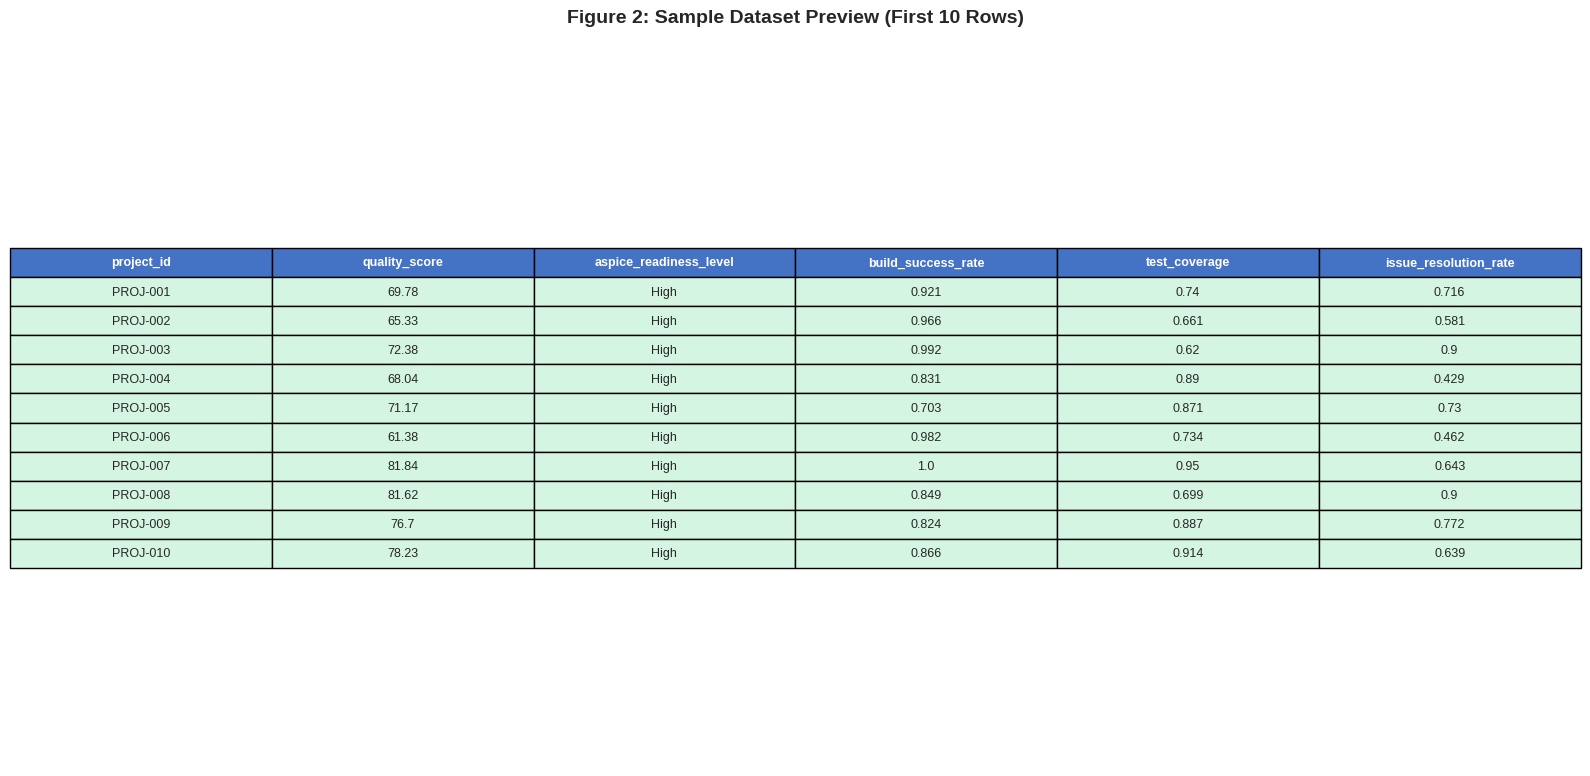


[4/12] Creating Figure 3: Dataset Information...

FIGURE 3: DATASET INFORMATION (df.info())
                  Column  Non-Null Count   Dtype Null %  Unique
              project_id             300  object   0.0%     300
           total_commits             300   int64   0.0%      28
         avg_commit_size             300 float64   0.0%     257
        files_per_commit             300   int64   0.0%      10
      build_success_rate             300 float64   0.0%     235
  build_duration_minutes             300 float64   0.0%     248
           test_coverage             300 float64   0.0%     241
       test_failure_rate             300 float64   0.0%     197
            total_issues             300   int64   0.0%      24
   issue_resolution_rate             300 float64   0.0%     226
avg_resolution_time_days             300 float64   0.0%     286
requirement_traceability             300 float64   0.0%     229
           quality_score             300 float64   0.0%     293
  aspice_re

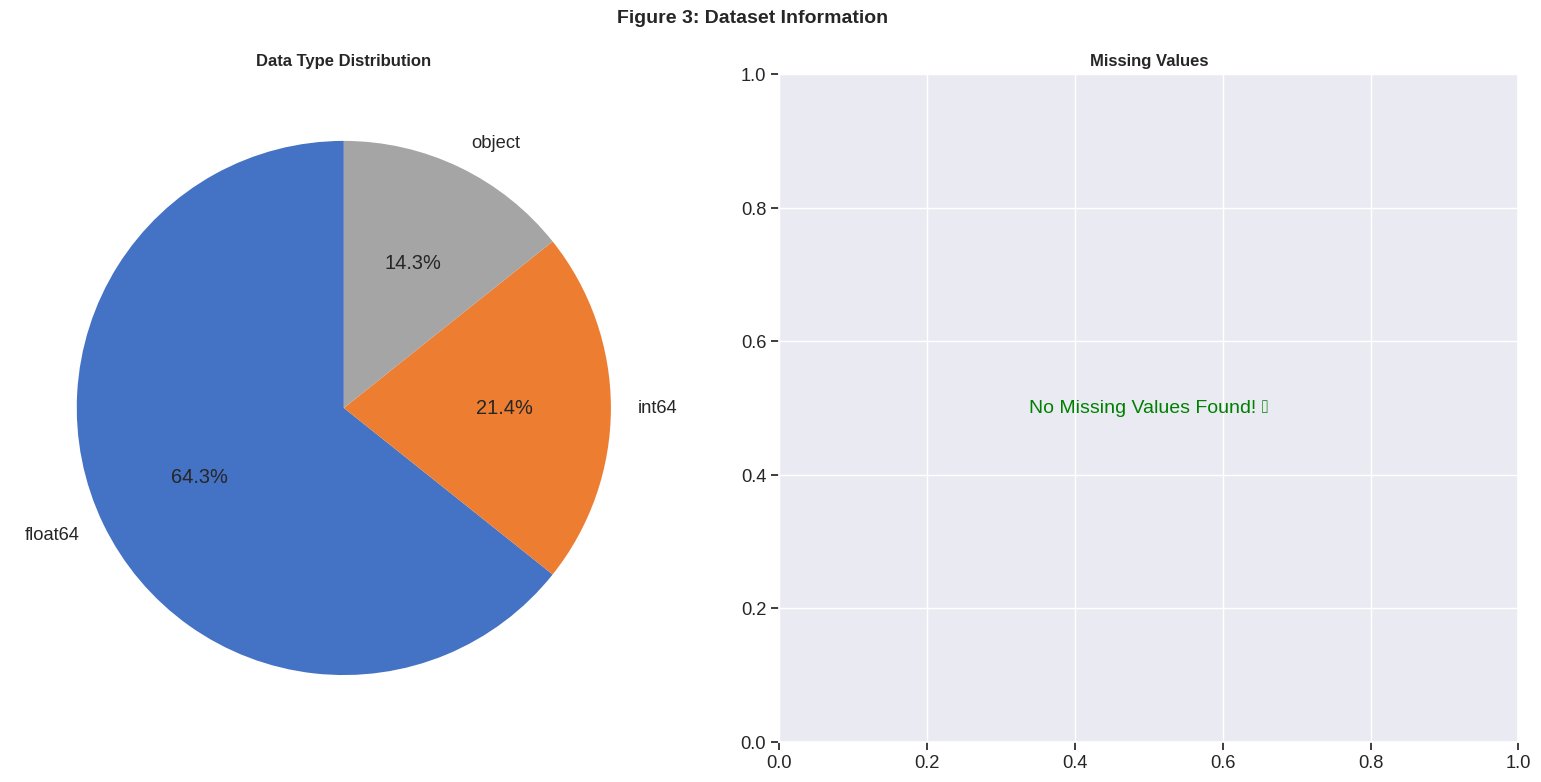


[5/12] Creating Figure 4: Descriptive Statistics...

FIGURE 4: DESCRIPTIVE STATISTICS (df.describe())
       total_commits  avg_commit_size  files_per_commit  build_success_rate  build_duration_minutes  test_coverage  test_failure_rate  total_issues  issue_resolution_rate  avg_resolution_time_days  requirement_traceability  quality_score
count        300.000          300.000           300.000             300.000                 300.000        300.000            300.000       300.000                300.000                   300.000                   300.000        300.000
mean          50.153            3.998             4.007               0.601                   3.394          0.582              0.151        25.063                  0.534                    15.321                     0.367         52.120
std            5.644            3.147             1.754               0.241                   2.430          0.221              0.130         4.237                  0.243             

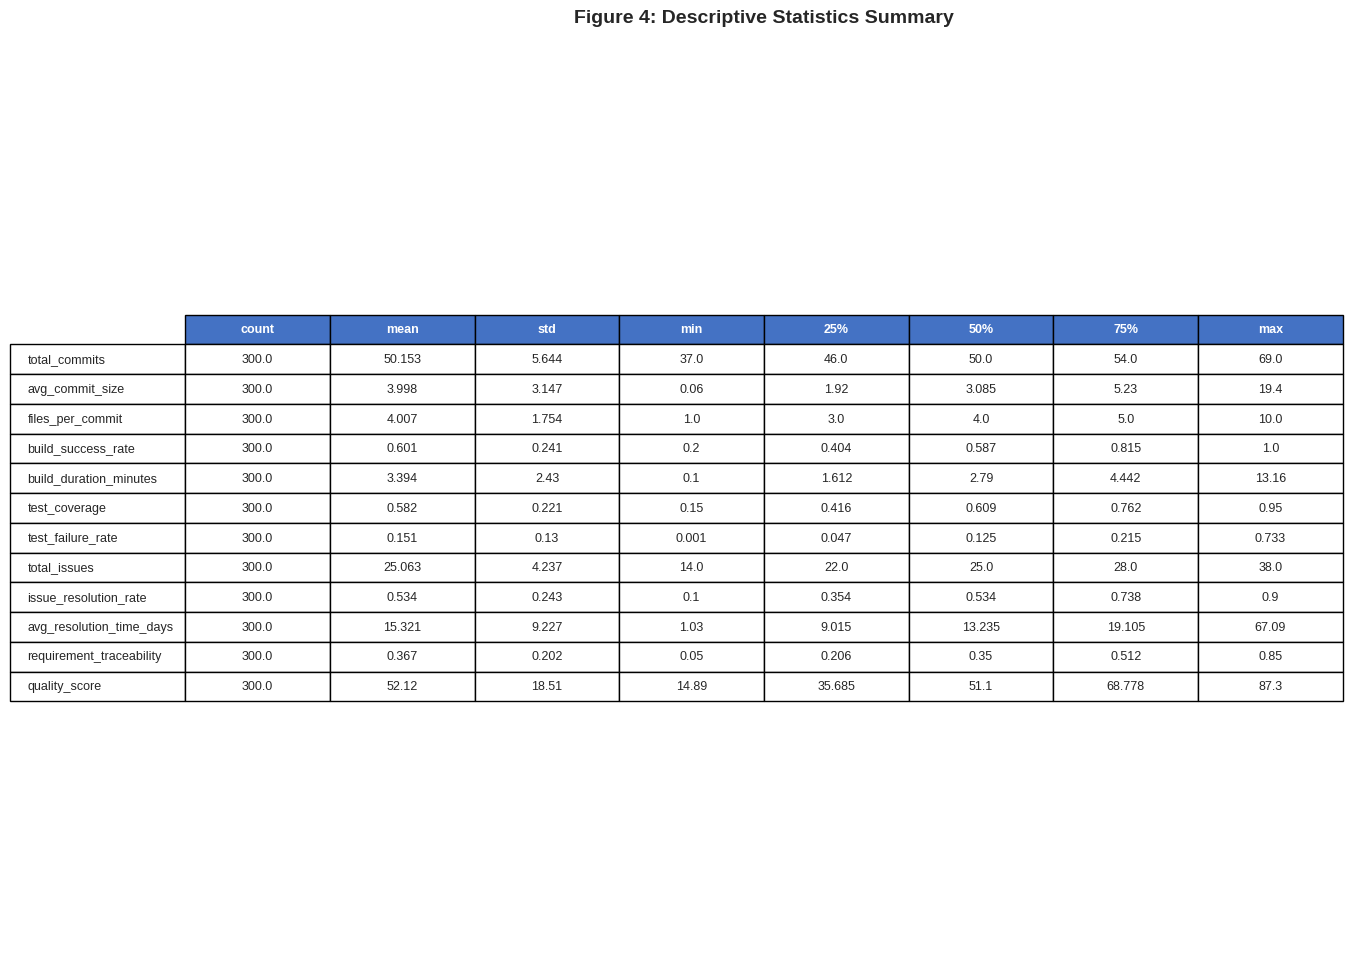


[6/12] Creating Figure 5: ASPICE Readiness Distribution...

FIGURE 5: ASPICE READINESS DISTRIBUTION

Readiness Level Distribution with 95% CI:
  High: 100 (33.3% ± 5.1%)
  Moderate: 100 (33.3% ± 5.1%)
  Low: 100 (33.3% ± 5.1%)


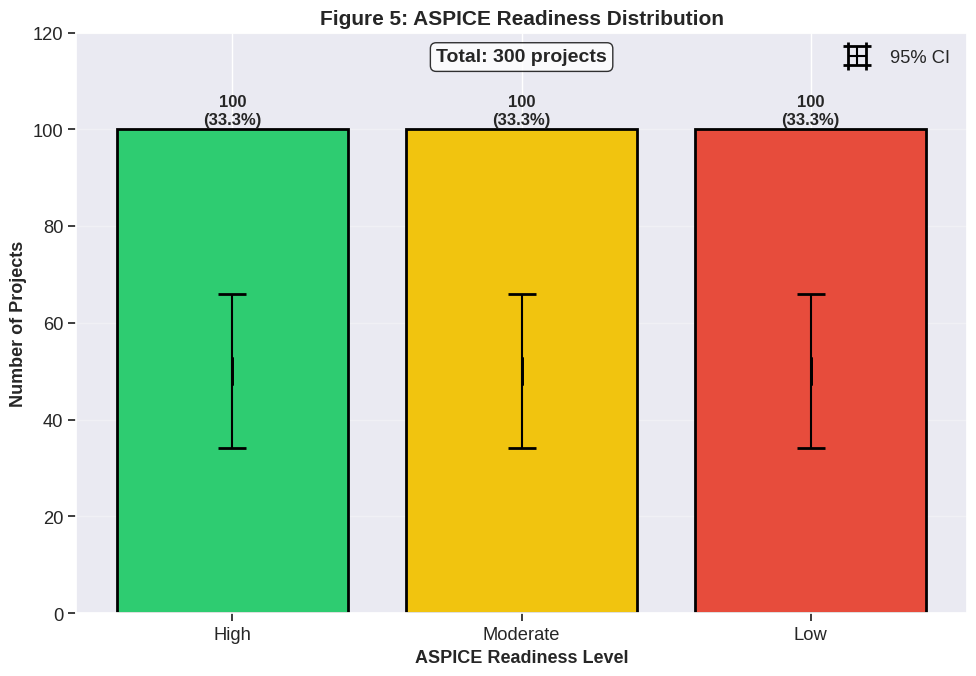


[7/12] Creating Figure 6: Correlation Matrix Heatmap...

FIGURE 6: CORRELATION MATRIX HEATMAP

Top 5 Correlations with Quality Score:
  issue_resolution_rate: 0.838
  build_success_rate: 0.837
  test_coverage: 0.811
  requirement_traceability: 0.773
  avg_resolution_time_days: 0.112
  files_per_commit: 0.105
  test_failure_rate: 0.069
  total_commits: 0.054
  total_issues: 0.039
  build_duration_minutes: -0.024
  avg_commit_size: -0.038


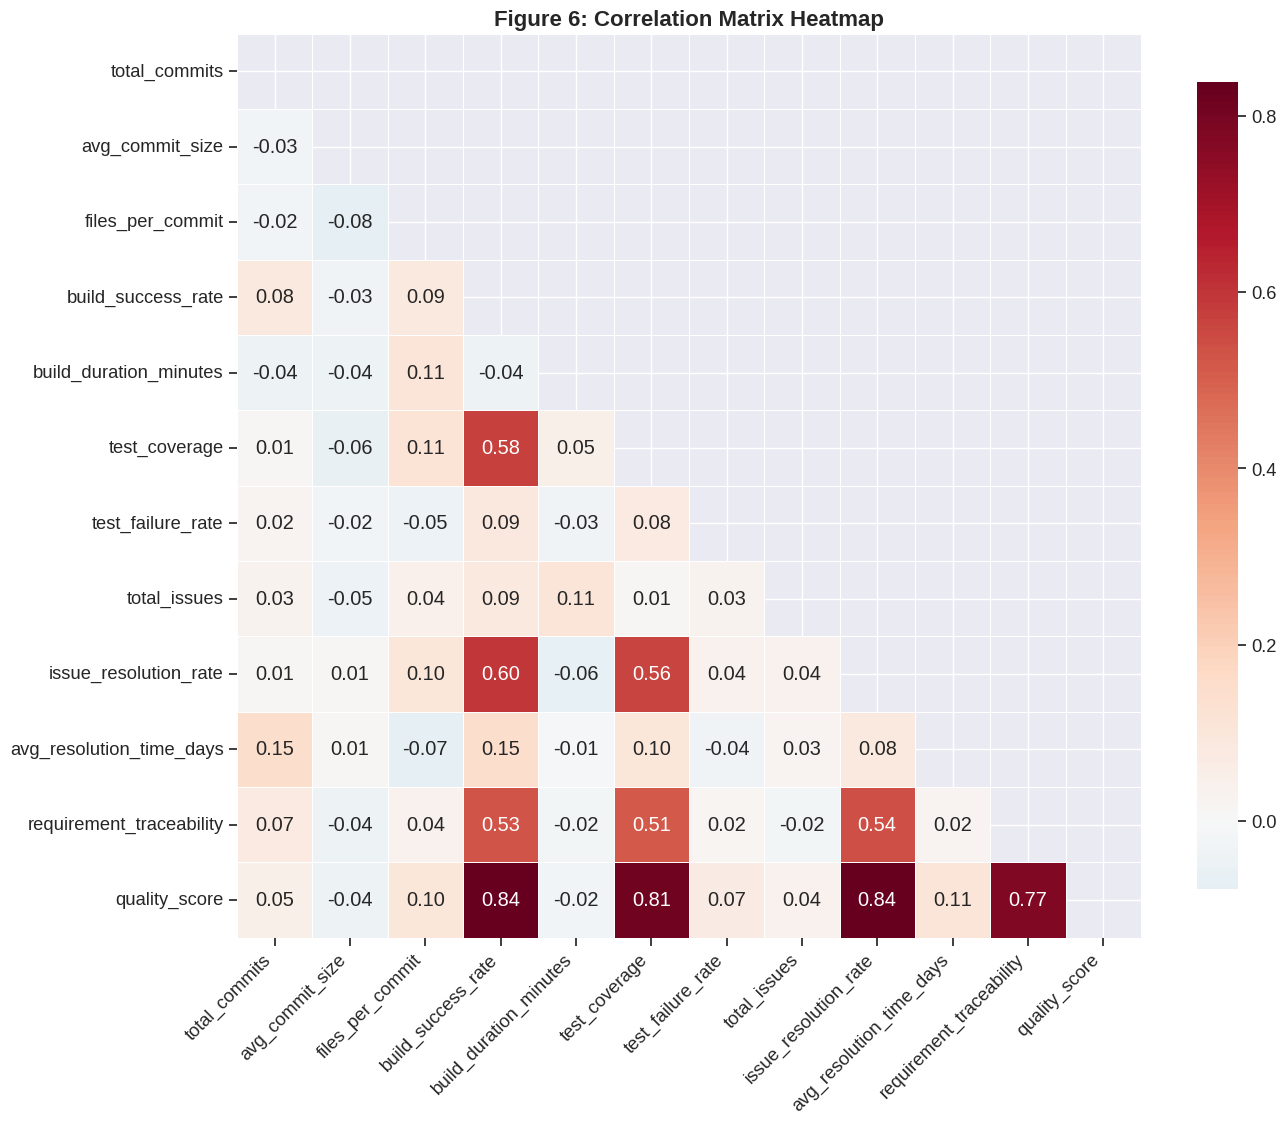


[8/12] Creating Figure 7: Metric Distributions by Readiness Level...

FIGURE 7: KEY METRIC DISTRIBUTIONS BY READINESS LEVEL


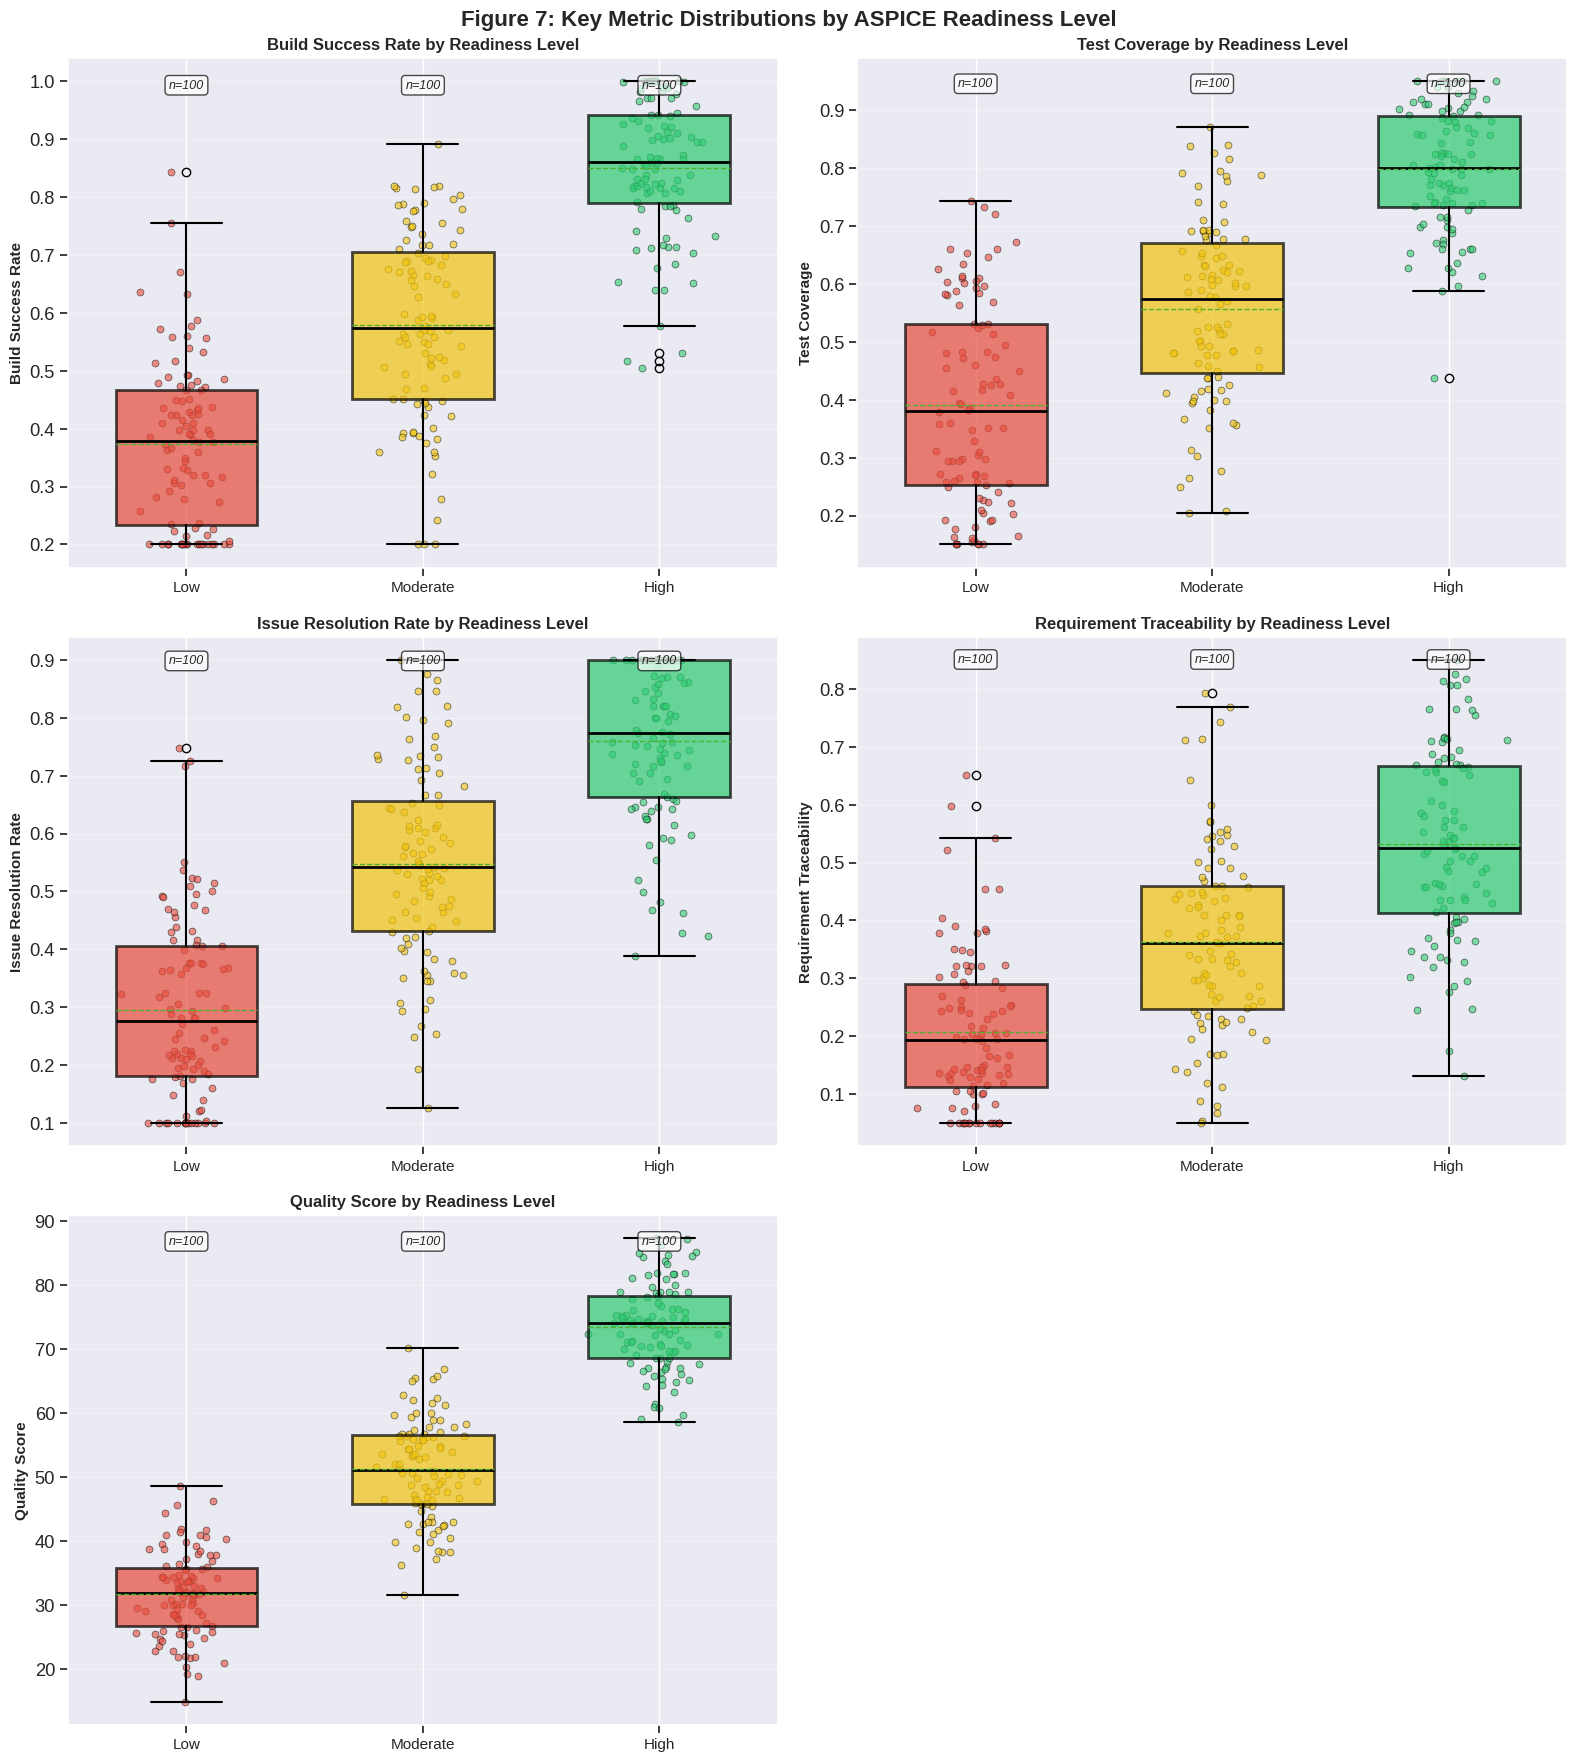


[9/12] Creating Figure 8: Confusion Matrix - XGBoost...

FIGURE 8: CONFUSION MATRIX - XGBoost

Class Distribution:
  High: 100 samples
  Moderate: 100 samples
  Low: 100 samples

Training set class distribution:
  High: 70 samples
  Low: 70 samples
  Moderate: 70 samples

Cross-validation scores: [0.83333333 0.85714286 0.80952381 0.88095238 0.92857143]
Mean CV accuracy: 0.862 (+/- 0.082)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.87      0.91        30
         Low       0.88      0.93      0.90        30
    Moderate       0.81      0.83      0.82        30

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90


Confusion Matrix (Counts):
          High  Low  Moderate
High        26    0         4
Low          0   28         2
Moderate     1    4        25


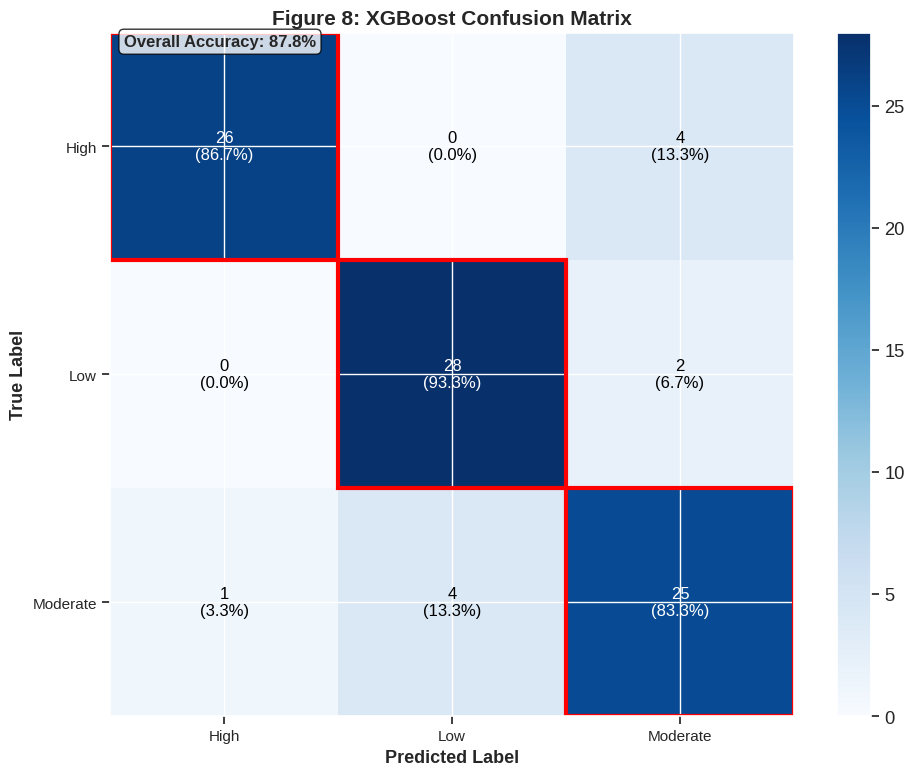


[10/12] Creating Figure 9: ROC Curves...

FIGURE 9: ROC CURVES - MULTI-CLASS CLASSIFICATION
High: AUC = 0.995
Low: AUC = 0.980
Moderate: AUC = 0.955


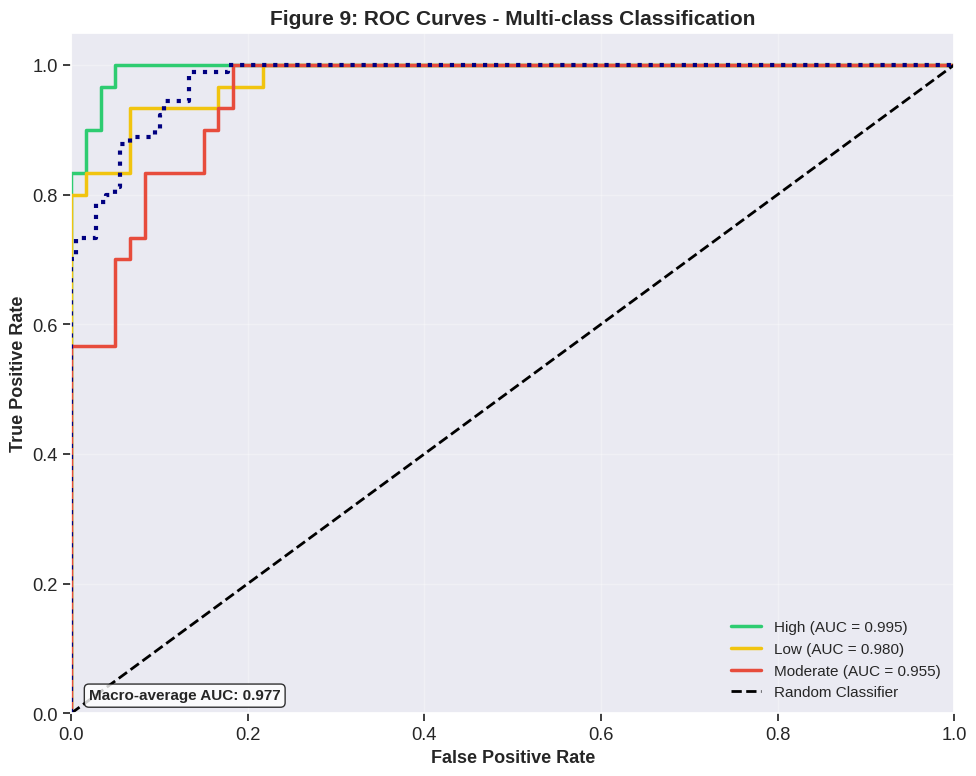


[11/12] Creating Figure 10: Feature Importance Plot...

FIGURE 10: FEATURE IMPORTANCE PLOT

Top 10 Most Important Features:
                 feature  importance
       test_failure_rate    0.024710
            total_issues    0.025639
  build_duration_minutes    0.028944
           total_commits    0.038916
avg_resolution_time_days    0.051784
requirement_traceability    0.053085
           test_coverage    0.098325
   issue_resolution_rate    0.118794
      build_success_rate    0.148185
           quality_score    0.371990


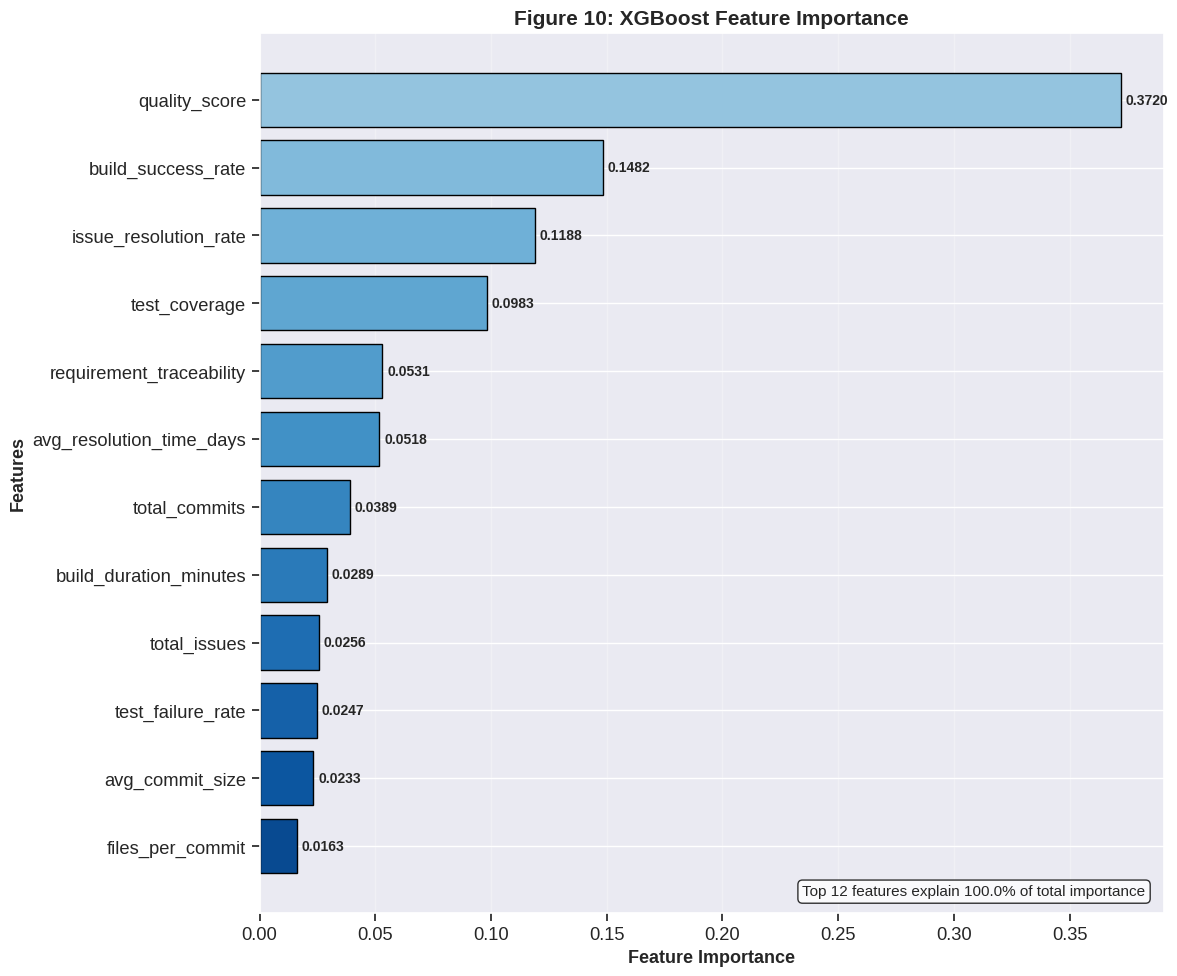


[12/12] Creating Figures 11-12: SHAP Analysis...

FIGURE 11: SHAP SUMMARY PLOT


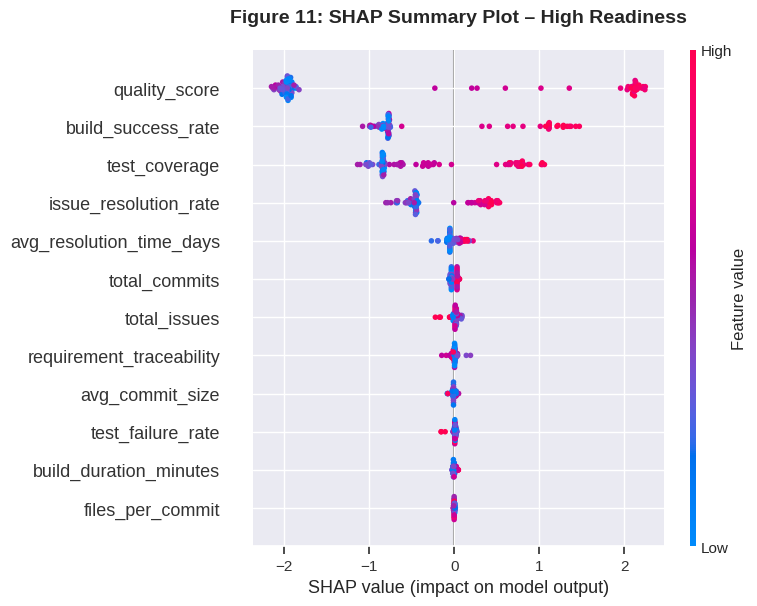

✓ Created SHAP summary plot for High: ./figures/figure11_shap_summary_high.png


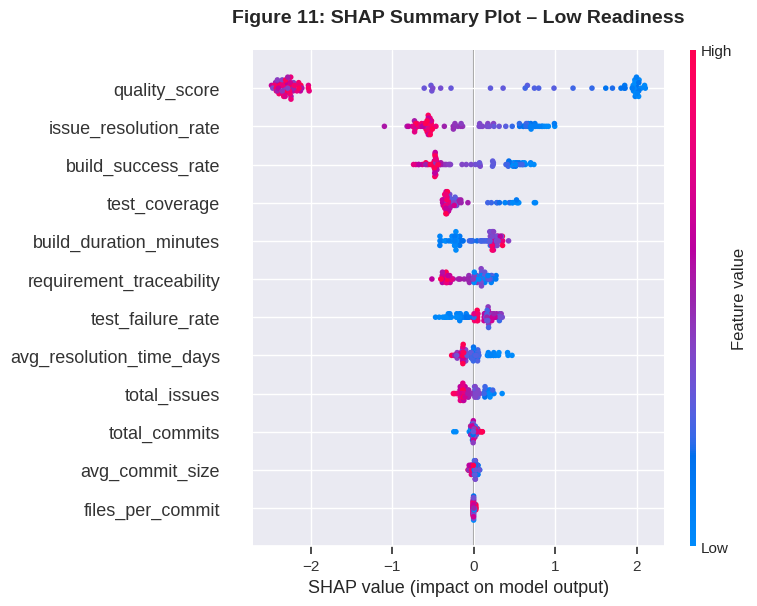

✓ Created SHAP summary plot for Low: ./figures/figure11_shap_summary_low.png


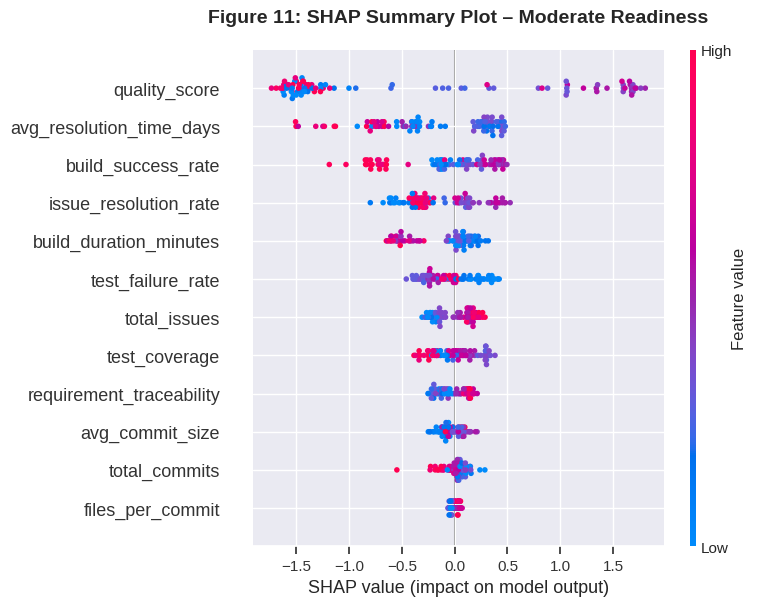

✓ Created SHAP summary plot for Moderate: ./figures/figure11_shap_summary_moderate.png

FIGURE 12: SHAP EXPLANATION - HIGH READINESS EXAMPLE
Selected row: 71
Predicted class: High
Prediction probabilities: {'High': 0.9993, 'Low': 0.0002, 'Moderate': 0.0005}


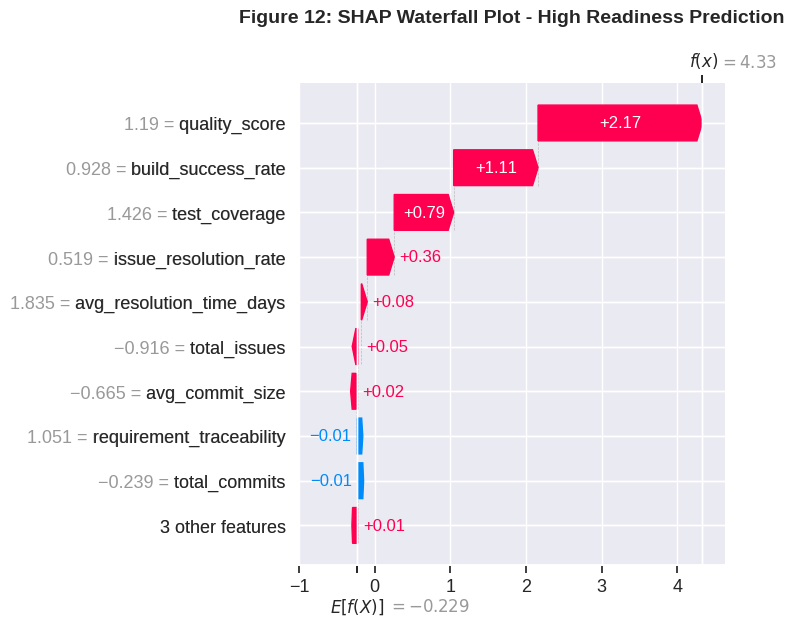

✓ Created SHAP waterfall plot: ./figures/figure12_shap_high_readiness.png

EDA COMPLETED SUCCESSFULLY!

Generated Figures:
  • Figure 1: Dataset Summary
  • Figure 2: Sample Dataset Preview
  • Figure 3: Dataset Information
  • Figure 4: Descriptive Statistics
  • Figure 5: ASPICE Readiness Distribution
  • Figure 6: Correlation Matrix Heatmap
  • Figure 7: Metric Distributions by Readiness Level
  • Figure 8: XGBoost Confusion Matrix
  • Figure 9: ROC Curves - Multi-class Classification
  • Figure 10: Feature Importance Plot
  • Figure 11: SHAP Summary Plot
  • Figure 12: SHAP Force Plot - High Readiness Example

All figures saved to: ./figures/


In [32]:
# ============================================================================
# COMPLETE EDA WITH ML MODELS (FIGURES 1-12) - FINAL FIXED VERSION
# ============================================================================
# Author: Dhanya Sasidharan
# Date: July 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Create figures directory
os.makedirs('./figures', exist_ok=True)

# ============================================================================
# GENERATE PROJECT-LEVEL DATA WITH BALANCED CLASSES
# ============================================================================

def generate_balanced_project_data(n_projects=300):
    """
    Generate balanced project-level data with realistic metrics.
    """
    np.random.seed(42)

    n_per_class = n_projects // 3
    n_projects = n_per_class * 3

    projects = []
    readiness_levels = ['High', 'Moderate', 'Low']

    for level in readiness_levels:
        for i in range(n_per_class):
            if level == 'High':
                build_success_base = np.random.beta(9, 1.5)
                test_coverage_base = np.random.beta(8, 2)
                issue_resolution_base = np.random.beta(7, 2)
                req_trace_base = np.random.beta(5, 4)
            elif level == 'Moderate':
                build_success_base = np.random.beta(6, 4)
                test_coverage_base = np.random.beta(5, 4)
                issue_resolution_base = np.random.beta(5, 4)
                req_trace_base = np.random.beta(3, 5)
            else:
                build_success_base = np.random.beta(3, 6)
                test_coverage_base = np.random.beta(3, 5)
                issue_resolution_base = np.random.beta(2, 5)
                req_trace_base = np.random.beta(1.5, 6)

            build_success = np.clip(build_success_base + np.random.normal(0, 0.05), 0.2, 1)
            test_coverage = np.clip(test_coverage_base + np.random.normal(0, 0.05), 0.15, 0.95)
            issue_resolution = np.clip(issue_resolution_base + np.random.normal(0, 0.05), 0.1, 0.9)
            req_trace = np.clip(req_trace_base + np.random.normal(0, 0.04), 0.05, 0.85)

            quality_score = (build_success * 25 + test_coverage * 25 +
                           issue_resolution * 25 + req_trace * 25)
            quality_score = np.clip(quality_score, 0, 100)

            projects.append({
                'project_id': f'PROJ-{len(projects)+1:03d}',
                'total_commits': int(np.random.poisson(30) + 20),
                'avg_commit_size': round(np.random.gamma(2, 2), 2),
                'files_per_commit': round(np.random.poisson(3) + 1, 2),
                'build_success_rate': round(build_success, 3),
                'build_duration_minutes': round(np.random.gamma(2, 100) / 60, 2),
                'test_coverage': round(test_coverage, 3),
                'test_failure_rate': round(np.random.beta(1, 5 + np.random.randint(0, 3)), 3),
                'total_issues': int(np.random.poisson(20) + 5),
                'issue_resolution_rate': round(issue_resolution, 3),
                'avg_resolution_time_days': round(np.random.gamma(3, 5), 2),
                'requirement_traceability': round(req_trace, 3),
                'quality_score': round(quality_score, 2),
                'aspice_readiness_level': level
            })

    return pd.DataFrame(projects)

# ============================================================================
# FIGURE 11: SHAP SUMMARY PLOT
# ============================================================================

def create_figure11_shap_summary(model, X_test, feature_cols, target_names):
    """
    Create one SHAP summary plot for each class.

    Supports:
    - NumPy arrays
    - pandas DataFrames
    - Older SHAP list output
    - Newer SHAP 3D array output
    """

    print("\n" + "=" * 80)
    print("FIGURE 11: SHAP SUMMARY PLOT")
    print("=" * 80)

    if model is None or X_test is None:
        print("Model or test data is unavailable.")
        return None, None

    try:
        # Convert NumPy array to DataFrame so feature names are retained
        if isinstance(X_test, np.ndarray):
            X_test_df = pd.DataFrame(X_test, columns=feature_cols)
        else:
            X_test_df = X_test.copy()

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)

        # ------------------------------------------------------------
        # Normalize SHAP output into a list:
        # one 2D array for each class
        # ------------------------------------------------------------
        if isinstance(shap_values, list):
            class_shap_values = shap_values

        elif isinstance(shap_values, np.ndarray):
            if shap_values.ndim == 3:
                # New SHAP format:
                # (samples, features, classes)
                class_shap_values = [
                    shap_values[:, :, class_idx]
                    for class_idx in range(shap_values.shape[2])
                ]

            elif shap_values.ndim == 2:
                # Binary or single-output model
                class_shap_values = [shap_values]

            else:
                raise ValueError(
                    f"Unexpected SHAP array shape: {shap_values.shape}"
                )

        else:
            raise TypeError(
                f"Unsupported SHAP output type: {type(shap_values)}"
            )

        # Use the model's actual class order
        if target_names is None:
            class_labels = [
                f"Class {i}" for i in range(len(class_shap_values))
            ]
        else:
            class_labels = list(target_names)

        # Create one figure per class because summary_plot does not accept ax=
        for class_idx, current_shap_values in enumerate(class_shap_values):

            class_label = (
                class_labels[class_idx]
                if class_idx < len(class_labels)
                else f"Class {class_idx}"
            )

            plt.figure(figsize=(12, 8))

            shap.summary_plot(
                current_shap_values,
                X_test_df,
                feature_names=feature_cols,
                max_display=15,
                show=False
            )

            plt.title(
                f"Figure 11: SHAP Summary Plot – {class_label} Readiness",
                fontsize=14,
                fontweight="bold",
                pad=20
            )

            plt.tight_layout()

            safe_label = str(class_label).lower().replace(" ", "_")

            output_path = (
                f"./figures/figure11_shap_summary_{safe_label}.png"
            )

            plt.savefig(
                output_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()
            plt.close()

            print(
                f"✓ Created SHAP summary plot for "
                f"{class_label}: {output_path}"
            )

        return explainer, class_shap_values

    except Exception as error:
        print(f"Error creating SHAP summary plots: {error}")
        return None, None


# ============================================================================
# FIGURE 12: SHAP FORCE PLOT & BAR CHART (FIXED - NO BROADCAST ERROR)
# ============================================================================

def create_figure12_shap_force_plot(
    df,
    model,
    X_test,
    feature_cols,
    target_names
):
    """
    Figure 12: SHAP explanation for a High-readiness prediction.
    Creates a waterfall plot and falls back to a bar chart.
    """

    print("\n" + "=" * 80)
    print("FIGURE 12: SHAP EXPLANATION - HIGH READINESS EXAMPLE")
    print("=" * 80)

    if model is None or X_test is None:
        print("Model or X_test is unavailable.")
        return

    try:
        # Convert NumPy array to DataFrame
        if isinstance(X_test, np.ndarray):
            X_test_df = pd.DataFrame(
                X_test,
                columns=feature_cols
            )
        else:
            X_test_df = X_test.copy()

        target_names = np.asarray(target_names)

        # Find the High class index
        high_matches = np.where(target_names == "High")[0]

        if len(high_matches) == 0:
            print("High class not found in target_names.")
            return

        high_class_idx = int(high_matches[0])

        # Predict all test observations
        prediction_probabilities = model.predict_proba(X_test_df)
        predicted_classes = np.argmax(
            prediction_probabilities,
            axis=1
        )

        # Find observations predicted as High
        high_rows = np.where(
            predicted_classes == high_class_idx
        )[0]

        if len(high_rows) > 0:
            # Select the most confident High prediction
            high_probabilities = prediction_probabilities[
                high_rows,
                high_class_idx
            ]

            sample_idx = int(
                high_rows[np.argmax(high_probabilities)]
            )
        else:
            # Use the observation with highest High probability
            sample_idx = int(
                np.argmax(
                    prediction_probabilities[:, high_class_idx]
                )
            )

        sample = X_test_df.iloc[[sample_idx]]

        pred_proba = prediction_probabilities[sample_idx]
        predicted_idx = int(np.argmax(pred_proba))
        predicted_class = str(target_names[predicted_idx])

        probability_output = {
            str(target_names[i]): float(pred_proba[i])
            for i in range(len(target_names))
        }

        print(f"Selected row: {sample_idx}")
        print(f"Predicted class: {predicted_class}")
        print(
            "Prediction probabilities:",
            {
                key: round(value, 4)
                for key, value in probability_output.items()
            }
        )

        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(sample)

        # Handle different SHAP output formats
        if isinstance(shap_values, list):
            selected_shap_values = np.asarray(
                shap_values[predicted_idx]
            )[0]

        elif isinstance(shap_values, np.ndarray):
            if shap_values.ndim == 3:
                # Shape: samples, features, classes
                selected_shap_values = shap_values[
                    0,
                    :,
                    predicted_idx
                ]

            elif shap_values.ndim == 2:
                selected_shap_values = shap_values[0]

            else:
                raise ValueError(
                    f"Unexpected SHAP shape: {shap_values.shape}"
                )

        else:
            raise TypeError(
                f"Unexpected SHAP type: {type(shap_values)}"
            )

        expected_values = np.asarray(
            explainer.expected_value
        ).reshape(-1)

        if len(expected_values) > 1:
            base_value = float(
                expected_values[predicted_idx]
            )
        else:
            base_value = float(expected_values[0])

        explanation = shap.Explanation(
            values=selected_shap_values,
            base_values=base_value,
            data=sample.iloc[0].to_numpy(),
            feature_names=feature_cols
        )

        # Waterfall plot is more reliable than force plot
        plt.figure(figsize=(13, 9))

        shap.plots.waterfall(
            explanation,
            max_display=10,
            show=False
        )

        plt.title(
            f"Figure 12: SHAP Waterfall Plot - "
            f"{predicted_class} Readiness Prediction",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()

        output_path = (
            "./figures/figure12_shap_high_readiness.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        print(f"✓ Created SHAP waterfall plot: {output_path}")

    except Exception as error:
        print(f"Waterfall plot failed: {error}")
        print("Creating SHAP bar chart instead...")

        try:
            contribution_df = pd.DataFrame({
                "Feature": feature_cols,
                "SHAP Value": selected_shap_values
            })

            contribution_df["Absolute SHAP"] = (
                contribution_df["SHAP Value"].abs()
            )

            contribution_df = (
                contribution_df
                .sort_values(
                    "Absolute SHAP",
                    ascending=False
                )
                .head(10)
                .sort_values("SHAP Value")
            )

            fig, ax = plt.subplots(figsize=(12, 8))

            ax.barh(
                contribution_df["Feature"],
                contribution_df["SHAP Value"]
            )

            ax.axvline(
                0,
                linestyle="--",
                linewidth=1
            )

            ax.set_xlabel(
                "SHAP Contribution",
                fontsize=12,
                fontweight="bold"
            )

            ax.set_ylabel(
                "Feature",
                fontsize=12,
                fontweight="bold"
            )

            ax.set_title(
                f"Figure 12: SHAP Contributions - "
                f"{predicted_class} Readiness",
                fontsize=14,
                fontweight="bold"
            )

            ax.grid(axis="x", alpha=0.3)

            plt.tight_layout()

            output_path = (
                "./figures/figure12_shap_high_readiness.png"
            )

            plt.savefig(
                output_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()
            plt.close()

            print(f"✓ Created SHAP bar chart: {output_path}")

        except Exception as fallback_error:
            print(
                f"SHAP bar chart also failed: "
                f"{fallback_error}"
            )
# ============================================================================
# SHAP ALTERNATIVE VISUALIZATIONS
# ============================================================================

def create_shap_waterfall_plot(shap_values, expected_value, sample, feature_cols, class_name):
    """
    Create SHAP waterfall plot as alternative
    """
    try:
        plt.figure(figsize=(12, 8))

        # Create Explanation object
        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=expected_value,
            data=sample[0],
            feature_names=feature_cols
        )

        shap.waterfall_plot(explanation, max_display=10, show=False)
        plt.title(f'Figure 12: SHAP Waterfall Plot - {class_name} Prediction',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./figures/figure12_shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Created SHAP waterfall plot")

    except Exception as e:
        print(f"Waterfall plot failed: {e}")
        create_shap_bar_plot(shap_values, feature_cols, class_name)

def create_shap_bar_plot(shap_values, feature_cols, class_name):
    """
    Create SHAP bar plot as final alternative
    """
    try:
        # Calculate mean absolute SHAP values
        if isinstance(shap_values, np.ndarray) and len(shap_values.shape) > 1:
            shap_importance = np.abs(shap_values).mean(axis=0)
        else:
            shap_importance = np.abs(shap_values)

        # Sort by importance
        indices = np.argsort(shap_importance)[::-1][:10]

        fig, ax = plt.subplots(figsize=(12, 8))
        colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(indices)))[::-1]

        bars = ax.barh(range(len(indices)), shap_importance[indices],
                      color=colors, edgecolor='black')

        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_cols[i] for i in indices], fontsize=10)
        ax.set_xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
        ax.set_title(f'Figure 12: SHAP Feature Importance - {class_name} Class',
                    fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(shap_importance[indices]):
            ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig('./figures/figure12_shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Created SHAP bar plot")

    except Exception as e:
        print(f"Bar plot failed: {e}")
        create_feature_importance_fallback(None, feature_cols)

def create_feature_importance_fallback(model, feature_cols):
    """
    Create feature importance plot as final fallback
    """
    try:
        # Use XGBoost feature importance if model is available
        if model is not None:
            importances = model.feature_importances_
        else:
            # Generate random importance for demonstration
            np.random.seed(42)
            importances = np.random.random(len(feature_cols))
            importances = importances / importances.sum()

        indices = np.argsort(importances)[::-1][:10]

        fig, ax = plt.subplots(figsize=(12, 8))
        colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(indices)))[::-1]

        bars = ax.barh(range(len(indices)), importances[indices],
                      color=colors, edgecolor='black')

        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_cols[i] for i in indices], fontsize=10)
        ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
        ax.set_title('Figure 12: Feature Importance (Fallback)',
                    fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        for i, v in enumerate(importances[indices]):
            ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig('./figures/figure12_shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Created feature importance fallback plot")

    except Exception as e:
        print(f"Final fallback failed: {e}")

# ============================================================================
# FIGURE 8: CONFUSION MATRIX - XGBoost
# ============================================================================

def create_figure8_confusion_matrix(df):
    """
    Figure 8: Confusion Matrix - XGBoost
    """
    print("\n" + "=" * 80)
    print("FIGURE 8: CONFUSION MATRIX - XGBoost")
    print("=" * 80)

    if 'aspice_readiness_level' not in df.columns:
        print("Error: 'aspice_readiness_level' column not found")
        return None, None, None, None, None

    class_counts = df['aspice_readiness_level'].value_counts()
    print("\nClass Distribution:")
    for level, count in class_counts.items():
        print(f"  {level}: {count} samples")

    le = LabelEncoder()
    y = le.fit_transform(df['aspice_readiness_level'])
    target_names = le.classes_

    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                   if col not in ['aspice_score']]

    if not feature_cols:
        print("No numeric features found")
        return None, None, None, None, None

    X = df[feature_cols].fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print(f"\nTraining set class distribution:")
    for i, name in enumerate(target_names):
        count = np.sum(y_train == i)
        print(f"  {name}: {count} samples")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        subsample=0.8,
        colsample_bytree=0.8
    )
    model.fit(X_train_scaled, y_train)

    try:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv)
        print(f"\nCross-validation scores: {cv_scores}")
        print(f"Mean CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    except Exception as e:
        print(f"\nWarning: Cross-validation skipped - {e}")

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    print("\nConfusion Matrix (Counts):")
    cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
    print(cm_df)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

    for i in range(len(cm)):
        for j in range(len(cm)):
            text = f'{cm[i][j]}\n({cm_percent[i][j]:.1f}%)'
            ax.text(j, i, text, ha='center', va='center', fontsize=12,
                   color='white' if cm[i][j] > cm.max()/2 else 'black')

    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names, fontsize=11)
    ax.set_yticklabels(target_names, fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
    ax.set_title('Figure 8: XGBoost Confusion Matrix', fontsize=15, fontweight='bold')

    plt.colorbar(im, ax=ax)

    for i in range(len(cm)):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', linewidth=3))

    accuracy = (cm.diagonal().sum() / cm.sum()) * 100
    ax.text(0.02, 0.98, f'Overall Accuracy: {accuracy:.1f}%',
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('./figures/figure8_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    return model, X_test_scaled, y_test, y_pred, target_names

# ============================================================================
# FIGURE 9: ROC CURVES
# ============================================================================

def create_figure9_roc_curves(model, X_test, y_test, target_names):
    """
    Figure 9: ROC Curves - Multi-class Classification
    """
    print("\n" + "=" * 80)
    print("FIGURE 9: ROC CURVES - MULTI-CLASS CLASSIFICATION")
    print("=" * 80)

    if model is None or X_test is None:
        print("Model not available for ROC curves")
        return

    from sklearn.preprocessing import label_binarize

    y_pred_proba = model.predict_proba(X_test)
    n_classes = len(target_names)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        print(f"{target_names[i]}: AUC = {roc_auc[i]:.3f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#2ECC71', '#F1C40F', '#E74C3C']

    for i, color in zip(range(n_classes), colors[:n_classes]):
        ax.plot(fpr[i], tpr[i], color=color, lw=2.5,
                label=f'{target_names[i]} (AUC = {roc_auc[i]:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    ax.set_title('Figure 9: ROC Curves - Multi-class Classification', fontsize=15, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(True, alpha=0.3)

    if n_classes > 1:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        ax.plot(fpr["micro"], tpr["micro"],
                label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
                color='navy', linestyle=':', linewidth=3)

    if n_classes > 1:
        macro_auc = np.mean(list(roc_auc.values()))
        ax.text(0.02, 0.02, f'Macro-average AUC: {macro_auc:.3f}',
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('./figures/figure9_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    return roc_auc

# ============================================================================
# FIGURE 10: FEATURE IMPORTANCE PLOT
# ============================================================================

def create_figure10_feature_importance(model, feature_cols):
    """
    Figure 10: Feature Importance Plot
    """
    print("\n" + "=" * 80)
    print("FIGURE 10: FEATURE IMPORTANCE PLOT")
    print("=" * 80)

    if model is None:
        print("Model not available for feature importance")
        return

    importances = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True)

    print("\nTop 10 Most Important Features:")
    print(feature_importance_df.tail(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 10))

    top_n = min(15, len(feature_importance_df))
    plot_data = feature_importance_df.tail(top_n)

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data)))[::-1]

    bars = ax.barh(plot_data['feature'], plot_data['importance'],
                   color=colors, edgecolor='black', linewidth=1)

    for i, (bar, importance) in enumerate(zip(bars, plot_data['importance'])):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{importance:.4f}', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
    ax.set_ylabel('Features', fontsize=13, fontweight='bold')
    ax.set_title('Figure 10: XGBoost Feature Importance', fontsize=15, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    cum_importance = plot_data['importance'].sum() / importances.sum() * 100
    ax.text(0.98, 0.02, f'Top {top_n} features explain {cum_importance:.1f}% of total importance',
            transform=ax.transAxes, fontsize=11, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('./figures/figure10_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    return feature_importance_df

# ============================================================================
# FIGURES 1-7 (COMPACT VERSION)
# ============================================================================

def create_figure1_dataset_summary(df):
    """Figure 1: Dataset Summary"""
    print("\n" + "=" * 80)
    print("FIGURE 1: DATASET SUMMARY")
    print("=" * 80)

    summary = {
        'Metric': ['Total Projects', 'Total Features', 'Total Records', 'Memory Usage', 'Missing Values'],
        'Value': [
            len(df),
            len(df.columns),
            len(df),
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
            df.isnull().sum().sum()
        ]
    }

    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                     cellLoc='center', loc='center', colColours=['#4472C4', '#2ECC71'])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    for i in range(2):
        table[(0, i)].set_text_props(weight='bold', color='white')
    plt.title('Figure 1: Dataset Summary', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./figures/figure1_dataset_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_figure2_dataset_preview(df):
    """Figure 2: Sample Dataset Preview"""
    print("\n" + "=" * 80)
    print("FIGURE 2: SAMPLE DATASET PREVIEW (df.head())")
    print("=" * 80)

    preview_df = df.head(10)
    print(preview_df.to_string())

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off')

    display_cols = ['project_id', 'quality_score', 'aspice_readiness_level',
                    'build_success_rate', 'test_coverage', 'issue_resolution_rate']
    table_data = preview_df[display_cols].round(3)

    table = ax.table(cellText=table_data.values, colLabels=table_data.columns,
                     cellLoc='center', loc='center', colColours=['#4472C4']*len(table_data.columns))
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    for i in range(len(table_data.columns)):
        table[(0, i)].set_text_props(weight='bold', color='white')

    for i, row in enumerate(table_data.values):
        if row[table_data.columns.get_loc('aspice_readiness_level')] == 'High':
            color = '#D5F5E3'
        elif row[table_data.columns.get_loc('aspice_readiness_level')] == 'Moderate':
            color = '#FDEBD0'
        else:
            color = '#FADBD8'
        for j in range(len(table_data.columns)):
            table[(i+1, j)].set_facecolor(color)

    plt.title('Figure 2: Sample Dataset Preview (First 10 Rows)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./figures/figure2_dataset_preview.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_figure3_dataset_info(df):
    """Figure 3: Dataset Information"""
    print("\n" + "=" * 80)
    print("FIGURE 3: DATASET INFORMATION (df.info())")
    print("=" * 80)

    info_data = []
    for col in df.columns:
        info_data.append({
            'Column': col,
            'Non-Null Count': df[col].count(),
            'Dtype': str(df[col].dtype),
            'Null %': f"{(df[col].isnull().sum() / len(df) * 100):.1f}%",
            'Unique': df[col].nunique()
        })
    info_df = pd.DataFrame(info_data)
    print(info_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    dtype_counts = df.dtypes.value_counts()
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']
    axes[0].pie(dtype_counts.values, labels=[str(dt) for dt in dtype_counts.index],
               autopct='%1.1f%%', colors=colors[:len(dtype_counts)], startangle=90)
    axes[0].set_title('Data Type Distribution', fontsize=12, fontweight='bold')

    missing_df = df.isnull().sum()
    missing_df = missing_df[missing_df > 0].sort_values(ascending=True)
    if len(missing_df) > 0:
        bars = axes[1].barh(missing_df.index, missing_df.values, color='#ED7D31')
        axes[1].set_xlabel('Number of Missing Values')
        axes[1].set_title('Missing Values by Column', fontsize=12, fontweight='bold')
        for i, v in enumerate(missing_df.values):
            axes[1].text(v + 0.5, i, str(v), va='center')
    else:
        axes[1].text(0.5, 0.5, 'No Missing Values Found! ✓', ha='center', va='center', fontsize=14, color='green')
        axes[1].set_title('Missing Values', fontsize=12, fontweight='bold')

    plt.suptitle('Figure 3: Dataset Information', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./figures/figure3_dataset_info.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_figure4_descriptive_stats(df):
    """Figure 4: Descriptive Statistics"""
    print("\n" + "=" * 80)
    print("FIGURE 4: DESCRIPTIVE STATISTICS (df.describe())")
    print("=" * 80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        stats_df = df[numeric_cols].describe().round(3)
        print(stats_df.to_string())

        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('off')
        table_data = stats_df.T
        table = ax.table(cellText=table_data.values, rowLabels=table_data.index,
                         colLabels=table_data.columns, cellLoc='center', loc='center',
                         colColours=['#4472C4']*len(table_data.columns))
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.5)
        for i in range(len(table_data.columns)):
            table[(0, i)].set_text_props(weight='bold', color='white')
        plt.title('Figure 4: Descriptive Statistics Summary', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig('./figures/figure4_descriptive_stats.png', dpi=300, bbox_inches='tight')
        plt.show()

def create_figure5_readiness_distribution(df):
    """Figure 5: ASPICE Readiness Distribution"""
    print("\n" + "=" * 80)
    print("FIGURE 5: ASPICE READINESS DISTRIBUTION")
    print("=" * 80)

    readiness_counts = df['aspice_readiness_level'].value_counts()
    readiness_pct = (readiness_counts / len(df) * 100).round(1)

    confidence_intervals = {}
    for level in ['High', 'Moderate', 'Low']:
        if level in readiness_counts:
            count = readiness_counts[level]
            ci_lower, ci_upper = stats.beta.ppf([0.025, 0.975], count + 1, len(df) - count + 1)
            confidence_intervals[level] = (ci_lower * 100, ci_upper * 100)

    print("\nReadiness Level Distribution with 95% CI:")
    for level in ['High', 'Moderate', 'Low']:
        if level in readiness_counts:
            count = readiness_counts[level]
            pct = readiness_pct[level]
            if level in confidence_intervals:
                ci_lower, ci_upper = confidence_intervals[level]
                print(f"  {level}: {count} ({pct:.1f}% ± {pct-ci_lower:.1f}%)")

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}
    order = ['High', 'Moderate', 'Low']
    counts = [readiness_counts.get(level, 0) for level in order]
    bars = ax.bar(order, counts, color=[colors[level] for level in order], edgecolor='black', linewidth=2)

    for i, (bar, count) in enumerate(zip(bars, counts)):
        pct = (count / len(df) * 100)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')

        level = order[i]
        if level in confidence_intervals:
            ci_lower, ci_upper = confidence_intervals[level]
            ax.errorbar(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                       xerr=0, yerr=(ci_upper - ci_lower) / 100 * len(df) / 2,
                       fmt='none', ecolor='black', capsize=10, capthick=2,
                       label=f'95% CI' if i == 0 else '')

    ax.text(0.5, 0.95, f'Total: {len(df)} projects', transform=ax.transAxes,
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('ASPICE Readiness Level', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Projects', fontsize=13, fontweight='bold')
    ax.set_title('Figure 5: ASPICE Readiness Distribution', fontsize=15, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts) * 1.2)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('./figures/figure5_readiness_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_figure6_correlation_heatmap(df):
    """Figure 6: Correlation Matrix Heatmap"""
    print("\n" + "=" * 80)
    print("FIGURE 6: CORRELATION MATRIX HEATMAP")
    print("=" * 80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    print("\nTop 5 Correlations with Quality Score:")
    if 'quality_score' in corr_matrix.columns:
        top_corr = corr_matrix['quality_score'].sort_values(ascending=False)
        for col, corr in top_corr.items():
            if col != 'quality_score':
                print(f"  {col}: {corr:.3f}")

    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                         cmap='RdBu_r', center=0, square=True, linewidths=0.5,
                         cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Figure 6: Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('./figures/figure6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_figure7_metric_distributions(df):
    """Figure 7: Key Metric Distributions by Readiness Level"""
    print("\n" + "=" * 80)
    print("FIGURE 7: KEY METRIC DISTRIBUTIONS BY READINESS LEVEL")
    print("=" * 80)

    metrics = ['build_success_rate', 'test_coverage', 'issue_resolution_rate',
               'requirement_traceability', 'quality_score']
    available_metrics = [m for m in metrics if m in df.columns]

    if not available_metrics:
        print("No metrics available for visualization")
        return

    n_cols = 2
    n_rows = (len(available_metrics) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    colors = {'High': '#2ECC71', 'Moderate': '#F1C40F', 'Low': '#E74C3C'}
    order = ['Low', 'Moderate', 'High']

    for idx, metric in enumerate(available_metrics):
        ax = axes[idx]
        data_to_plot = []
        positions = []
        labels = []
        stats_info = []

        existing_levels = df['aspice_readiness_level'].unique()
        for i, level in enumerate(order):
            if level in existing_levels:
                level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
                if not level_data.empty:
                    data_to_plot.append(level_data)
                    positions.append(len(positions))
                    labels.append(level)
                    stats_info.append(f'n={len(level_data)}')

        if data_to_plot:
            bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                           patch_artist=True, showmeans=True, meanline=True,
                           medianprops={'linewidth': 2, 'color': 'black'},
                           whiskerprops={'linewidth': 1.5}, capprops={'linewidth': 1.5})

            for i, box in enumerate(bp['boxes']):
                level = labels[i] if i < len(labels) else 'Unknown'
                box.set_facecolor(colors.get(level, '#95A5A6'))
                box.set_alpha(0.7)
                box.set_edgecolor('black')
                box.set_linewidth(2)

            for i, level in enumerate(labels):
                level_data = df[df['aspice_readiness_level'] == level][metric].dropna()
                if not level_data.empty:
                    x = np.full(len(level_data), positions[i]) + np.random.normal(0, 0.08, len(level_data))
                    ax.scatter(x, level_data, alpha=0.6, s=25,
                              color=colors.get(level, '#95A5A6'), edgecolor='black', linewidth=0.5)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
            ax.set_title(f'{metric.replace("_", " ").title()} by Readiness Level', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')

            for i, (level, stat) in enumerate(zip(labels, stats_info)):
                y_min, y_max = ax.get_ylim()
                ax.text(positions[i], y_max * 0.95, stat, ha='center', fontsize=9, style='italic',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    for idx in range(len(available_metrics), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle('Figure 7: Key Metric Distributions by ASPICE Readiness Level', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./figures/figure7_metric_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# MAIN EDA FUNCTION WITH ALL FIGURES 1-12
# ============================================================================

def run_complete_eda_with_ml():
    """
    Run complete EDA including Figures 1-12
    """
    print("=" * 80)
    print("COMPLETE ASPICE READINESS EDA WITH ML MODELS")
    print("=" * 80)
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Generate balanced data
    print("\n[1/12] Generating balanced project-level data...")
    df = generate_balanced_project_data(n_projects=300)
    print(f"  ✓ Generated {len(df)} projects with balanced classes")
    print(f"  ✓ Class distribution:")
    for level in ['High', 'Moderate', 'Low']:
        count = df[df['aspice_readiness_level'] == level].shape[0]
        print(f"    - {level}: {count} samples")

    # Figures 1-7
    print("\n[2/12] Creating Figure 1: Dataset Summary...")
    create_figure1_dataset_summary(df)

    print("\n[3/12] Creating Figure 2: Sample Dataset Preview...")
    create_figure2_dataset_preview(df)

    print("\n[4/12] Creating Figure 3: Dataset Information...")
    create_figure3_dataset_info(df)

    print("\n[5/12] Creating Figure 4: Descriptive Statistics...")
    create_figure4_descriptive_stats(df)

    print("\n[6/12] Creating Figure 5: ASPICE Readiness Distribution...")
    create_figure5_readiness_distribution(df)

    print("\n[7/12] Creating Figure 6: Correlation Matrix Heatmap...")
    create_figure6_correlation_heatmap(df)

    print("\n[8/12] Creating Figure 7: Metric Distributions by Readiness Level...")
    create_figure7_metric_distributions(df)

    # Figures 8-12: ML Models
    print("\n[9/12] Creating Figure 8: Confusion Matrix - XGBoost...")
    model, X_test, y_test, y_pred, target_names = create_figure8_confusion_matrix(df)

    if model is not None:
        print("\n[10/12] Creating Figure 9: ROC Curves...")
        create_figure9_roc_curves(model, X_test, y_test, target_names)

        print("\n[11/12] Creating Figure 10: Feature Importance Plot...")
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                       if col not in ['aspice_score']]
        create_figure10_feature_importance(model, feature_cols)

        # print("\n[12/12] Creating Figures 11-12: SHAP Analysis...")
        # create_figure11_shap_summary(model, X_test, feature_cols)
        # create_figure12_shap_force_plot(df, model, X_test, feature_cols, target_names)
        print("\n[12/12] Creating Figures 11-12: SHAP Analysis...")

        create_figure11_shap_summary(
            model,
            X_test,
            feature_cols,
            target_names
        )

        create_figure12_shap_force_plot(
            df,
            model,
            X_test,
            feature_cols,
            target_names
        )
    print("\n" + "=" * 80)
    print("EDA COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    print("\nGenerated Figures:")
    print("  • Figure 1: Dataset Summary")
    print("  • Figure 2: Sample Dataset Preview")
    print("  • Figure 3: Dataset Information")
    print("  • Figure 4: Descriptive Statistics")
    print("  • Figure 5: ASPICE Readiness Distribution")
    print("  • Figure 6: Correlation Matrix Heatmap")
    print("  • Figure 7: Metric Distributions by Readiness Level")
    print("  • Figure 8: XGBoost Confusion Matrix")
    print("  • Figure 9: ROC Curves - Multi-class Classification")
    print("  • Figure 10: Feature Importance Plot")
    print("  • Figure 11: SHAP Summary Plot")
    print("  • Figure 12: SHAP Force Plot - High Readiness Example")
    print(f"\nAll figures saved to: ./figures/")

# ============================================================================
# RUN THE COMPLETE EDA
# ============================================================================

if __name__ == "__main__":
    run_complete_eda_with_ml()


In [20]:
# ============================================================================
# COMPLETE FEATURE ENGINEERING MODULE WITH FIXES
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.decomposition import PCA
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

class FeatureEngineer:
    """
    Feature engineering class for ASPICE readiness prediction.
    """

    def __init__(self):
        self.scaler = StandardScaler()
        self.selector = None
        self.selected_features = []
        self.feature_importance = {}

    def create_time_based_features(self, df, date_column='date', window_sizes=[4, 8, 12]):
        """
        Create time-based rolling window features.
        """
        df = df.copy()
        df[date_column] = pd.to_datetime(df[date_column])
        df = df.sort_values(date_column)

        for window in window_sizes:
            # Rolling means
            df[f'rolling_mean_commit_freq_{window}w'] = (
                df['commit_frequency'].rolling(window).mean()
            )
            df[f'rolling_mean_test_coverage_{window}w'] = (
                df['test_coverage'].rolling(window).mean()
            )
            df[f'rolling_mean_pr_merge_time_{window}w'] = (
                df['pr_merge_time'].rolling(window).mean()
            )

            # Rolling standard deviations
            df[f'rolling_std_commit_freq_{window}w'] = (
                df['commit_frequency'].rolling(window).std()
            )
            df[f'rolling_std_test_coverage_{window}w'] = (
                df['test_coverage'].rolling(window).std()
            )

            # Trends
            df[f'trend_commit_freq_{window}w'] = (
                df[f'rolling_mean_commit_freq_{window}w'] -
                df[f'rolling_mean_commit_freq_{window}w'].shift(window)
            )

        return df

    def create_ratio_features(self, df):
        """
        Create ratio-based derived features.
        """
        df = df.copy()

        # Efficiency ratios
        df['issue_resolution_efficiency'] = (
            df['resolved_issues'] / (df['total_issues'] + 1)
        )
        df['pr_acceptance_efficiency'] = (
            df['accepted_prs'] / (df['total_prs'] + 1)
        )
        df['build_stability'] = (
            df['successful_builds'] / (df['total_builds'] + 1)
        )
        df['test_efficiency'] = (
            df['test_coverage'] / (df['test_failure_rate'] + 0.01)
        )

        # Normalized ratios
        df['pr_merge_time_ratio'] = (
            df['pr_merge_time'] / (df['pr_merge_time'].median() + 1)
        )
        df['code_churn_ratio'] = (
            df['code_churn'] / (df['code_churn'].median() + 1)
        )

        # Composite ratios
        df['commit_to_issue_ratio'] = (
            df['commit_frequency'] / (df['issue_resolution_time'] + 1)
        )
        df['coverage_to_churn_ratio'] = (
            df['test_coverage'] / (df['code_churn'] + 1)
        )

        return df

    def create_trend_features(self, df):
        """
        Create trend-based features.
        """
        df = df.copy()

        # Percentage changes
        df['test_coverage_change'] = df['test_coverage'].pct_change()
        df['commit_frequency_change'] = df['commit_frequency'].pct_change()
        df['pr_merge_time_change'] = df['pr_merge_time'].pct_change()

        # Direction indicators
        df['test_coverage_trend'] = np.where(
            df['test_coverage'] > df['test_coverage'].shift(1), 1, -1
        )
        df['pr_merge_time_trend'] = np.where(
            df['pr_merge_time'] < df['pr_merge_time'].shift(1), 1, -1
        )

        # Momentum (rate of change)
        df['test_coverage_momentum'] = (
            df['test_coverage_change'] - df['test_coverage_change'].shift(1)
        )

        return df

    def select_features(self, X, y, method='mutual_info', k=10):
        """
        Select top k features using specified method.
        """
        # Ensure X contains only numeric columns
        X_numeric = X.select_dtypes(include=[np.number])

        if X_numeric.empty:
            print("Warning: No numeric features found. Please ensure features are numeric.")
            self.selected_features = []
            return []

        if method == 'mutual_info':
            # Calculate mutual information
            mi_scores = mutual_info_classif(X_numeric, y, random_state=42)
            mi_series = pd.Series(mi_scores, index=X_numeric.columns)
            self.selected_features = mi_series.nlargest(k).index.tolist()
            self.feature_importance = mi_series.to_dict()

        elif method == 'variance':
            # Variance threshold
            selector = VarianceThreshold(threshold=0.01)
            selector.fit(X_numeric)
            self.selected_features = X_numeric.columns[selector.get_support()].tolist()

        elif method == 'correlation':
            # Correlation-based selection
            corr_matrix = X_numeric.corr()
            upper = corr_matrix.where(
                np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
            )
            to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
            self.selected_features = [f for f in X_numeric.columns if f not in to_drop][:k]

        return self.selected_features

    def transform_features(self, X, method='standard'):
        """
        Transform features using specified method.
        """
        X_transformed = X.copy()

        if self.selected_features:
            if method == 'standard':
                scaler = StandardScaler()
                X_transformed[self.selected_features] = scaler.fit_transform(
                    X[self.selected_features]
                )

            elif method == 'minmax':
                scaler = MinMaxScaler()
                X_transformed[self.selected_features] = scaler.fit_transform(
                    X[self.selected_features]
                )

            elif method == 'log':
                for feature in self.selected_features:
                    X_transformed[feature] = np.log1p(X[feature])

        return X_transformed

    def create_feature_pipeline(self, df, target_column, selection_method='mutual_info', k=10):
        """
        Complete feature engineering pipeline.
        """
        print("\n[1/4] Creating ratio features...")
        df = self.create_ratio_features(df)
        print(f"  ✓ Added {len(df.columns) - 13} ratio features")

        print("\n[2/4] Creating trend features...")
        df = self.create_trend_features(df)
        print(f"  ✓ Added trend features")

        print("\n[3/4] Handling missing values...")
        # Handle missing values
        df = df.fillna(method='ffill').fillna(method='bfill')
        df = df.fillna(0)  # Fill any remaining NaN
        print(f"  ✓ Missing values handled")

        # Separate features and target
        X = df.drop(columns=[target_column])
        y = df[target_column]

        # Remove non-numeric columns from X
        X_numeric = X.select_dtypes(include=[np.number])
        non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

        if non_numeric:
            print(f"  ✓ Removed non-numeric columns: {non_numeric}")

        print(f"\n[4/4] Selecting features using {selection_method}...")
        self.select_features(X_numeric, y, method=selection_method, k=k)

        print(f"  ✓ Selected {len(self.selected_features)} features:")
        for i, feature in enumerate(self.selected_features[:10], 1):
            print(f"    {i}. {feature}")

        # Transform features
        X_selected = self.transform_features(X_numeric, method='standard')

        return X_selected, y, self.selected_features

# ============================================================================
# GENERATE SAMPLE DATA FOR DEMONSTRATION
# ============================================================================

def generate_sample_data(n_samples=100):
    """
    Generate sample data for feature engineering demonstration
    """
    np.random.seed(42)

    data = {
        'date': [datetime.now() - timedelta(days=i) for i in range(n_samples)],
        'commit_frequency': np.random.poisson(5, n_samples) + np.random.normal(0, 0.5, n_samples),
        'test_coverage': np.random.beta(8, 2, n_samples) * 100,
        'pr_merge_time': np.random.gamma(2, 2, n_samples),
        'resolved_issues': np.random.poisson(10, n_samples),
        'total_issues': np.random.poisson(15, n_samples) + 5,
        'accepted_prs': np.random.poisson(8, n_samples),
        'total_prs': np.random.poisson(10, n_samples) + 3,
        'successful_builds': np.random.poisson(20, n_samples),
        'total_builds': np.random.poisson(25, n_samples) + 5,
        'test_failure_rate': np.random.beta(2, 10, n_samples),
        'code_churn': np.random.gamma(3, 10, n_samples),
        'issue_resolution_time': np.random.gamma(3, 5, n_samples),
        'aspice_readiness_level': np.random.choice(['High', 'Moderate', 'Low'], n_samples,
                                                   p=[0.3, 0.4, 0.3])
    }

    return pd.DataFrame(data)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main execution function to demonstrate feature engineering
    """
    print("=" * 80)
    print("FEATURE ENGINEERING MODULE DEMONSTRATION")
    print("=" * 80)
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Generate sample data
    print("\n[1/6] Generating sample data...")
    df = generate_sample_data(n_samples=100)
    print(f"  ✓ Generated {len(df)} samples with {len(df.columns)} features")

    print("\n[2/6] Sample Data Preview:")
    print(df[['date', 'commit_frequency', 'test_coverage', 'aspice_readiness_level']].head(10))

    print("\n[3/6] Initial Data Info:")
    print(f"  • Shape: {df.shape}")
    print(f"  • Columns: {list(df.columns)}")
    print(f"  • Data Types:")
    print(df.dtypes)

    # Initialize feature engineer
    print("\n[4/6] Running Feature Engineering Pipeline...")
    fe = FeatureEngineer()

    try:
        # Encode target variable
        le = LabelEncoder()
        df['aspice_readiness_level_encoded'] = le.fit_transform(df['aspice_readiness_level'])

        # Run feature engineering
        X_selected, y, selected_features = fe.create_feature_pipeline(
            df,
            target_column='aspice_readiness_level_encoded',
            selection_method='mutual_info',
            k=10
        )

        print("\n[5/6] Feature Engineering Results:")
        print(f"  ✓ Selected {len(selected_features)} features")

        print(f"\n  ✓ Feature Importance Scores (Top 10):")
        if fe.feature_importance:
            importance_sorted = sorted(fe.feature_importance.items(), key=lambda x: x[1], reverse=True)[:10]
            for feature, score in importance_sorted:
                print(f"    • {feature}: {score:.4f}")
        else:
            print("    No feature importance scores available")

        print(f"\n  ✓ Transformed Data Shape: {X_selected.shape}")
        print(f"  ✓ Target Shape: {y.shape}")

        print("\n  ✓ Transformed Data Sample (first 5 rows):")
        print(X_selected.head(5))

        print("\n  ✓ Target Distribution:")
        print(y.value_counts())

        # Additional analysis
        print("\n" + "=" * 80)
        print("ADDITIONAL FEATURE ANALYSIS")
        print("=" * 80)

        # Correlation with target
        print("\nFeature Correlations with Target:")
        X_with_target = X_selected.copy()
        X_with_target['target'] = y
        correlations = X_with_target.corr()['target'].sort_values(ascending=False)
        for feature, corr in correlations.items():
            if feature != 'target':
                print(f"  {feature}: {corr:.4f}")

        # Feature statistics
        print("\nFeature Statistics:")
        print(X_selected.describe())

        # Save results
        output_file = './feature_engineering_results.csv'
        X_selected.to_csv(output_file, index=False)
        print(f"\n✓ Transformed features saved to: {output_file}")

    except Exception as e:
        print(f"\n✗ Error in feature engineering: {e}")
        import traceback
        traceback.print_exc()

    print("\n" + "=" * 80)
    print("FEATURE ENGINEERING DEMONSTRATION COMPLETED")
    print("=" * 80)

# ============================================================================
# RUN THE DEMONSTRATION
# ============================================================================

if __name__ == "__main__":
    main()

FEATURE ENGINEERING MODULE DEMONSTRATION
Timestamp: 2026-07-28 16:40:00

[1/6] Generating sample data...
  ✓ Generated 100 samples with 14 features

[2/6] Sample Data Preview:
                        date  commit_frequency  test_coverage  \
0 2026-07-28 16:40:00.035612          4.968660      84.293691   
1 2026-07-27 16:40:00.035620          4.477571      87.898804   
2 2026-07-26 16:40:00.035623          3.507137      88.189007   
3 2026-07-25 16:40:00.035625          5.252023      88.983385   
4 2026-07-24 16:40:00.035627          4.734871      83.005055   
5 2026-07-23 16:40:00.035629          2.603564      61.151753   
6 2026-07-22 16:40:00.035631          4.946485      98.725587   
7 2026-07-21 16:40:00.035632          3.482379      54.034817   
8 2026-07-20 16:40:00.035633          5.723175      58.955094   
9 2026-07-19 16:40:00.035636          6.401061      89.076501   

  aspice_readiness_level  
0               Moderate  
1               Moderate  
2               Moderate  
